<a href="https://colab.research.google.com/github/jnolorbe/hydrology-peru/blob/main/notebooks/02_spatiotemporal_trends_and_enso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Spatiotemporal Trends and ENSO Teleconnections in Peruvian Hydrographic Domains

**Project:** Spatio-temporal Analysis of Hydrological Response in Peru (2002–2025)

**Author:** Prof. Juan Mendoza-Nolorbe

**Affiliation:** Universidad Nacional Mayor de San Marcos (UNMSM)

**Phase 2:** Spatiotemporal Trend Analysis and ENSO Climate Teleconnections

---

### Overview: Statistical Analysis Pipeline

This notebook provides a comprehensive assessment of the spatio-temporal dynamics of Terrestrial Water Storage (TWS) across Peru's 14 Hydrographic Domains (AAA), using GRACE/GRACE-FO satellite gravimetry data (2002–2025). The workflow is organised into seven sequential sections:

| Section | Description |
|---------|-------------|
| **I. Fundamentals** | Conceptual framework: spatial aggregation, cross-domain synchronisation, and latitudinal dynamics |
| **II. Data Loading** | Installation, repository sync, GRACE and shapefile ingestion, and preliminary inspection |
| **III. Time Series by Domain** | Spatial clipping, spatial mean extraction, and smoothing |
| **IV. Signal Decomposition** | Additive decomposition into Trend + Seasonal + Residual components |
| **V. ONI & ICEN Teleconnections** | Hovmöller diagrams, inter-domain TLCC, and peak lag analysis |
| **VI. Climate Forcing (TLCC)** | Time-lagged cross-correlation of standardised ONI/ICEN vs. TWS |
| **VII. C & E Index Teleconnections** | TLCC analysis using the IGP C and E indices |

> **Reproducibility note:** All data are retrieved directly from the cloned GitHub repository. Only the `GITHUB_USERNAME` variable in Section II needs to be updated when forking the project.


# I. Conceptual Framework and Analytical Rationale

This section presents the theoretical and methodological justification for the three main analytical axes developed in this notebook. Understanding these principles is essential for correctly interpreting the results in subsequent sections.


## 1.1. Spatial Aggregation by Hydrographic Domains

Peru is geographically divided into three macro-basins with markedly contrasting climatic regimes: the **Pacific (coastal)**, the **Atlantic (Amazonian)**, and the **Titicaca** basins. By aggregating the GRACE pixel-level TWS signal into the 14 Administrative Hydrographic Domains (AAA), we reduce spatial noise and obtain a robust regional water balance. This approach enables a meaningful comparative analysis between the hyper-arid Pacific coast and the humid Amazon rainforest, capturing regime-scale hydrological variability rather than sub-pixel artefacts.


## 1.2. Cross-Domain Synchronisation

The Andes Cordillera functions as a major orographic divide and atmospheric barrier. Cross-domain correlation analysis (Section IV) quantifies the degree to which TWS anomalies on one side of the mountains (Atlantic/Amazon) co-vary with anomalies on the other side (Pacific/Coast). High correlations with short lags suggest teleconnected forcing (e.g., ENSO); low or lagged correlations indicate locally-controlled moisture dynamics. This metric is fundamental for understanding national-scale hydrological responses to large-scale climate drivers.


## 1.3. Latitudinal Propagation Dynamics (Hovmöller Diagrams)

Standard time-series plots collapse all spatial information into a single signal, masking the geographical trajectory of anomalies. Hovmöller diagrams resolve this by reducing longitude to a latitudinal axis, allowing the reader to track how droughts or surplus water storage events propagate north-to-south across the 14 domains over time. When overlaid with ENSO indices (ONI, ICEN, C and E), this visualisation directly links oceanic forcing to its hydrological footprint at the regional scale.


# II. Environment Setup and Data Loading

This section prepares the computational environment and loads all datasets required for subsequent analyses. Steps are organised sequentially: library installation → imports → global plot settings → repository synchronisation → GRACE data → AAA shapefiles → preliminary inspection.


## 2.1. Library Installation and Imports

Install any non-standard libraries needed for NetCDF processing, spatial analysis, and scientific visualisation. All packages are available on PyPI and compatible with Google Colab, JupyterHub, and local Jupyter environments.


In [ ]:
# ── Install non-standard libraries ──────────────────────────────────────────
# Run once per environment. Safe to re-run (pip is idempotent).
# - cmcrameri : perceptually uniform scientific colormaps (Batlow, Vik, etc.)
# - netCDF4   : low-level NetCDF4 backend required by xarray
# - xarray    : labelled N-D arrays for GRACE spatio-temporal data
# - rioxarray : rasterio extension for spatial clipping with shapefiles
# - geopandas : vector geodata and CRS handling
# - shapely   : geometric operations (dissolve, centroid, area)
# - openpyxl  : optional Excel I/O for tabular exports
!pip install --quiet cmcrameri netCDF4 xarray rioxarray geopandas shapely openpyxl


In [2]:
# ── Core scientific stack ────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import rioxarray  # noqa: F401 — registers .rio accessor on xarray objects

# ── Visualisation helpers ────────────────────────────────────────────────────
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import cmcrameri.cm as cmc
import seaborn as sns

# ── Statistical libraries ────────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

print("✓ All libraries imported successfully.")


✓ All libraries imported successfully.


In [3]:
# ── Global matplotlib style for publication-quality figures ─────────────────
# These settings apply globally so every subsequent figure inherits them.

# Embed TrueType fonts (Type 42) for PDF/PS export compatibility
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Font family: Arial preferred; fallback chain ensures portability across systems
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans']

# Legible font sizes scaled for typical journal figure widths
plt.rcParams['font.size']        = 10
plt.rcParams['axes.labelsize']   = 10
plt.rcParams['axes.titlesize']   = 10
plt.rcParams['legend.fontsize']  = 10
plt.rcParams['xtick.labelsize']  = 10
plt.rcParams['ytick.labelsize']  = 10

# Clean, unobtrusive line weights
plt.rcParams['lines.linewidth'] = 1.0
plt.rcParams['axes.linewidth']  = 1.0

print("✓ Matplotlib global style configured.")


✓ Matplotlib global style configured.


## 2.2. Repository Synchronisation

All processed data, ENSO indices, and shapefiles are stored in the companion GitHub repository. The cell below clones the repository on first run and pulls the latest changes on subsequent runs.

> **To fork:** change `GITHUB_USERNAME` to your own GitHub handle before running.


In [4]:
# ── Repository configuration ─────────────────────────────────────────────────
REPO_NAME       = "hydrology-peru"
GITHUB_USERNAME = "jnolorbe"            # ← Update this if you fork the repository
REPO_URL        = f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

# ── Clone or update ──────────────────────────────────────────────────────────
if not os.path.exists(REPO_NAME):
    print(f"Cloning repository from {REPO_URL} ...")
    !git clone {REPO_URL}
    print("✓ Repository cloned successfully.")
else:
    print("Repository already exists. Pulling latest changes ...")
    %cd {REPO_NAME}
    !git pull
    %cd ..
    print("✓ Repository updated.")


Cloning repository from https://github.com/jnolorbe/hydrology-peru.git ...
Cloning into 'hydrology-peru'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 132 (delta 35), reused 5 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 55.25 MiB | 19.05 MiB/s, done.
Resolving deltas: 100% (35/35), done.
✓ Repository cloned successfully.


## 2.3. Loading GRACE/GRACE-FO Processed Dataset

The GRACE Mascon product was pre-processed in Notebook 01 (outlier removal via IQR 1.5×, gap imputation, and spatial masking to Peru). Both the pre-mission gap (January–March 2002) and the GRACE/GRACE-FO inter-mission gap (July 2017–May 2018) were imputed during that preprocessing stage; the loaded file contains a continuous, gap-free monthly record ready for analysis.

The resulting NetCDF file contains the variable `lwe_thickness_corrected` (Liquid Water Equivalent thickness, cm). Here we load the file, update its metadata to comply with CF conventions, and derive TWS anomalies by subtracting the long-term temporal mean.


In [ ]:
# ── File path (relative to repository root) ──────────────────────────────────
GRACE_PATH = os.path.join(REPO_NAME, "data/processed/GRACE_Peru_final_IQR1_5.nc")

# ── Load dataset ─────────────────────────────────────────────────────────────
try:
    xr_grace = xr.open_dataset(GRACE_PATH)
    print(f"✓ GRACE dataset loaded | Time steps: {len(xr_grace.time)} months")
except FileNotFoundError:
    raise FileNotFoundError(
        f"NetCDF file not found at '{GRACE_PATH}'. "
        "Verify that the repository was cloned correctly and that Notebook 01 was executed."
    )

# ── Update metadata to CF conventions ────────────────────────────────────────
# rioxarray and spatial libraries rely on these attributes for CRS handling.
xr_grace.attrs.update({
    "long_name"  : "Equivalent Water Height",
    "units"      : "cm",
    "crs"        : "+proj=longlat +datum=WGS84",
    "ellipsoid"  : "WGS84",
    "res"        : (0.5, 0.5),
    "nodatavals" : "nan",
})

# Drop the auxiliary 'month' variable (integer month labels, not needed downstream)
if 'month' in xr_grace:
    xr_grace = xr_grace.drop_vars('month')

# ── Compute TWS anomalies ─────────────────────────────────────────────────────
# Anomaly = Observation − Long-term mean (climatological baseline over full record)
# This centres the signal around zero and isolates departures from average storage.
long_term_mean = xr_grace['lwe_thickness_corrected'].mean('time')
xr_grace['lwe_thickness_centered'] = xr_grace['lwe_thickness_corrected'] - long_term_mean
xr_grace['lwe_thickness_centered'].attrs.update({
    'long_name': 'TWS Anomaly (mean-centred)',
    'units'    : 'cm'
})

display(xr_grace)


## 2.4. Loading Hydrographic Domain Boundaries (Shapefiles)

The 14 Administrative Hydrographic Authority (AAA) domains define the spatial units used throughout this analysis. The shapefile was sourced from Peru's National Water Authority (ANA) and is stored in the repository. We verify CRS alignment with the GRACE grid (WGS84 / EPSG:4326) and reproject if necessary.


In [ ]:
# ── Shapefile path ────────────────────────────────────────────────────────────
AAA_PATH = os.path.join(
    REPO_NAME, "data/shapefiles/hydroAAA_domains/Autoridad_Administrativa_del_Agua.shp"
)

# ── Load and validate ────────────────────────────────────────────────────────
try:
    gdf_aaa = gpd.read_file(AAA_PATH)

    # Ensure CRS alignment with the GRACE raster (EPSG:4326 = WGS84 geographic)
    if gdf_aaa.crs.to_epsg() != 4326:
        gdf_aaa = gdf_aaa.to_crs(epsg=4326)
        print("  CRS reprojected → EPSG:4326 (WGS84)")

    print(f"✓ AAA shapefile loaded | Domains: {gdf_aaa['CODE_AAA'].nunique()}")
    display(gdf_aaa[['CODE_AAA', 'NAME_AAA', 'geometry']].head())

except Exception as e:
    raise RuntimeError(
        f"Failed to load AAA shapefile at '{AAA_PATH}'. "
        f"Check the repository structure. Details: {e}"
    )


## 2.5. Visualisation of the 14 Hydrogeological Domains

This map provides spatial context for all subsequent analyses. Domains are coloured using the **Batlow** perceptually uniform colormap (Crameri et al., 2020). Numeric labels inside each polygon correspond to the plotting order used consistently throughout this notebook.


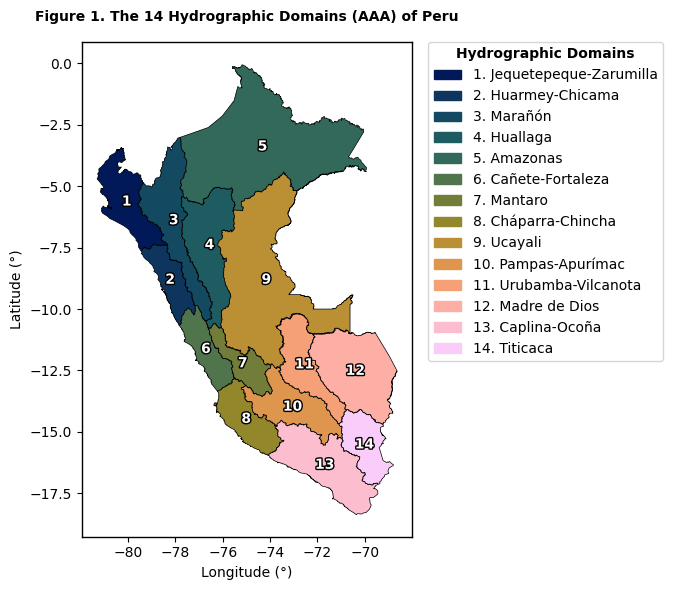

In [7]:
# ── Domain plotting configuration ────────────────────────────────────────────
# Each tuple: (CODE_AAA, display_label)
# Order follows a hydrological/latitudinal logic (North Pacific → South Andean → Amazonian)
REGION_ORDER = [
    (5,  'Jequetepeque-Zarumilla'),
    (4,  'Huarmey-Chicama'),
    (6,  'Marañón'),
    (8,  'Huallaga'),
    (7,  'Amazonas'),
    (3,  'Cañete-Fortaleza'),
    (10, 'Mantaro'),
    (2,  'Cháparra-Chincha'),
    (9,  'Ucayali'),
    (11, 'Pampas-Apurímac'),
    (12, 'Urubamba-Vilcanota'),
    (13, 'Madre de Dios'),
    (1,  'Caplina-Ocoña'),
    (14, 'Titicaca'),
]

# Generate Batlow palette with one colour per domain
batlow_colors = cmc.batlow(np.linspace(0, 1, len(REGION_ORDER)))

# Build lookup dict: CODE_AAA → {label, color, index}
region_meta = {
    code: {'label': label, 'color': batlow_colors[i], 'index': i + 1}
    for i, (code, label) in enumerate(REGION_ORDER)
}

# Reverse mapping: uppercase domain name → assigned number (used in all figures)
name_to_number = {label.upper(): idx for idx, (_, label) in enumerate(REGION_ORDER, start=1)}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for code, meta in region_meta.items():
    subset = gdf_aaa[gdf_aaa['CODE_AAA'] == code]
    if subset.empty:
        continue
    subset.plot(ax=ax, color=meta['color'], edgecolor='black', linewidth=0.5)

    # Centroid in projected CRS for accurate placement, then back to geographic
    centroid_proj = subset.to_crs(epsg=3857).geometry.centroid.iloc[0]
    centroid_geo  = gpd.GeoSeries([centroid_proj], crs='epsg:3857').to_crs(epsg=4326).iloc[0]
    ax.text(
        centroid_geo.x, centroid_geo.y, str(meta['index']),
        fontsize=10, ha='center', va='center', color='white', weight='bold',
        path_effects=[patheffects.withStroke(linewidth=2, foreground='black')]
    )

legend_handles = [
    mpatches.Patch(color=meta['color'], label=f"{meta['index']}. {meta['label']}")
    for meta in region_meta.values()
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left',
          borderaxespad=0., fontsize=10, title='Hydrographic Domains',
          title_fontproperties={'weight': 'bold'})

ax.set_title("Figure 1. The 14 Hydrographic Domains (AAA) of Peru",fontweight='bold', pad=15)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.grid(False)
plt.tight_layout()
plt.show()
plt.close()


## 2.6. Preliminary Spatial and Temporal Inspection of GRACE Data

Two quick sanity checks before domain-level aggregation:
1. **Spatial snapshot** — single-date TWS anomaly map to verify spatial coverage.
2. **Pixel time series** — representative time series for a central Peruvian pixel to confirm the data record and verify anomaly centring.


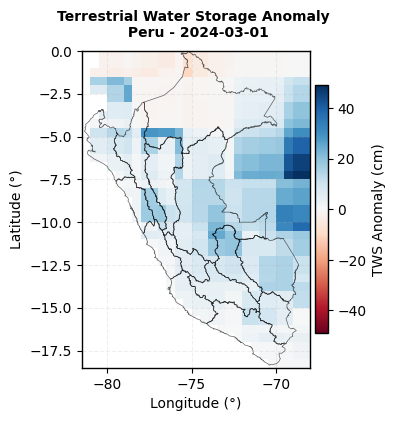

In [9]:
# ── 1. Spatial snapshot: TWS anomaly for a selected date ─────────────────────
TARGET_DATE = '2024-03-01'
tws_map = xr_grace['lwe_thickness_centered'].sel(time=TARGET_DATE, method='nearest')

fig, ax = plt.subplots(figsize=(4, 5))
im = tws_map.plot(ax=ax, cmap='RdBu', center=0, add_colorbar=False)
gdf_aaa.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.6)
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
cbar.set_label('TWS Anomaly (cm)', fontsize=10)

ax.set_title(f"Terrestrial Water Storage Anomaly \n Peru - {str(tws_map.time.values)[:10]}", fontweight='bold', pad=10)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()
plt.close(fig)


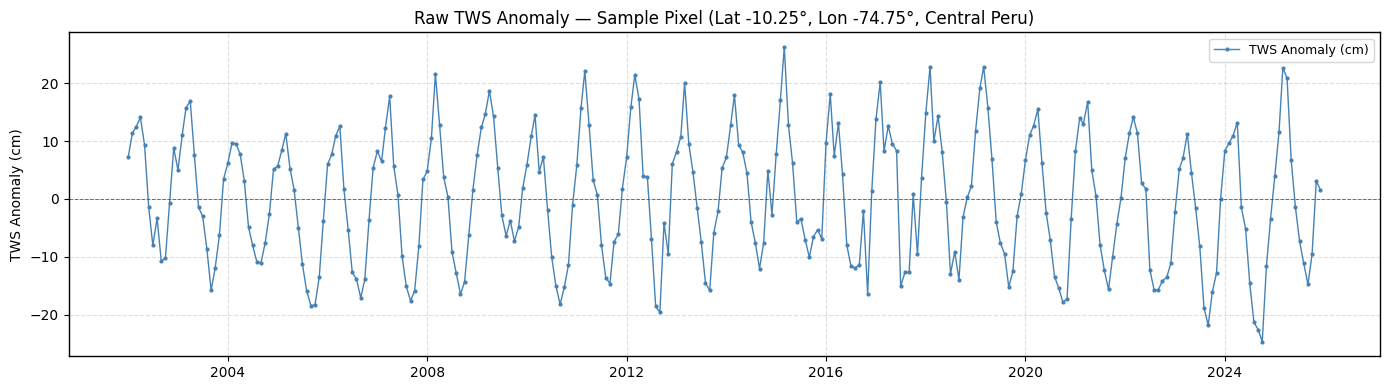

In [10]:
# ── 2. Pixel time series: temporal consistency check ─────────────────────────
# Selecting a representative pixel in central Peru (Amazonian footprint of the Andes)
PIXEL_LAT, PIXEL_LON = -10.25, -74.75

ts_pixel = xr_grace['lwe_thickness_centered'].sel(
    lat=PIXEL_LAT, lon=PIXEL_LON, method='nearest'
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts_pixel.time.values, ts_pixel.values,
        marker='o', markersize=2, linestyle='-', linewidth=1,
        color='steelblue', label='TWS Anomaly (cm)')
ax.axhline(0, color='red', linestyle='--', linewidth=0.7, alpha=0.8)
ax.set_title(
    f"Raw TWS Anomaly — Sample Pixel (Lat {PIXEL_LAT}°, Lon {PIXEL_LON}°, Central Peru)",
    fontsize=12
)
ax.set_ylabel("TWS Anomaly (cm)")
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()


### 📊 Section II — Results Summary

**GRACE Dataset:** The loaded product covers 2002–2025 at 0.5° spatial resolution. Both known data gaps (pre-mission and inter-mission) were imputed in Notebook 01; the loaded file contains a continuous, gap-free monthly record.

**TWS Anomaly Centring:** Subtracting the long-term mean produces a zero-centred signal. Positive values indicate above-average water storage (wet anomalies); negative values indicate below-average storage (drought conditions).

**AAA Domains:** 14 Hydrographic Administrative domains were loaded successfully, with geometries correctly aligned to EPSG:4326. The spatial map confirms complete coverage of the Peruvian territory, from the arid Jequetepeque-Zarumilla coastal domain in the northwest to the Titicaca endorheic basin in the southeast.


# III. Domain-Level Time Series Extraction

This section transforms the 2D GRACE raster (lat × lon × time) into 14 scalar time series, one per Hydrogeological Domain. The process involves: (1) spatial clipping of the raster to each domain boundary, (2) spatial mean calculation across all valid pixels within each domain to obtain a 1D monthly signal, and (3) application of a centred 3-month moving average to attenuate high-frequency noise while preserving inter-annual variability.


## 3.1. Spatial Clipping to Domain Boundaries

Each domain polygon is used to mask the GRACE raster. For domains with fragmented geometries (e.g., Ucayali), only the largest polygon is retained to avoid contamination from small administrative artefacts outside the main hydrological body.


In [ ]:
# ── Assign CRS to the GRACE DataArray before clipping ────────────────────────
# rioxarray requires an explicit CRS to perform spatial clip operations.
grace_anomaly_crs = xr_grace['lwe_thickness_centered'].rio.write_crs("EPSG:4326")

# ── Spatial clipping loop ─────────────────────────────────────────────────────
grace_clipped_domains = {}   # {CODE_AAA: clipped DataArray}
domain_ids = sorted(gdf_aaa['CODE_AAA'].unique())

for obj_id in domain_ids:
    domain_geoms = gdf_aaa[gdf_aaa['CODE_AAA'] == obj_id].copy()
    if domain_geoms.empty:
        print(f"  [WARNING] Domain {obj_id}: no geometry found, skipping.")
        continue

    # Select the largest polygon to exclude small administrative fragments
    domain_geoms['area_m2'] = domain_geoms.geometry.area
    main_geom   = domain_geoms.sort_values('area_m2', ascending=False).iloc[[0]]
    domain_name = main_geom['NAME_AAA'].iloc[0]

    # Clip GRACE raster: only pixels whose centre falls inside the polygon
    clipped = grace_anomaly_crs.rio.clip(
        main_geom.geometry, main_geom.crs,
        drop=True, all_touched=False
    )
    grace_clipped_domains[obj_id] = clipped
    print(f"  ✓ Domain {obj_id:>2} | {domain_name}")

print(f"✓ Clipping complete — {len(grace_clipped_domains)} domains processed.")


## 3.2. Spatial Mean Extraction and Temporal Smoothing

For each domain, the spatial mean is computed across all valid GRACE pixels, collapsing the 2D spatial dimensions into a single monthly time series. A centred 3-month rolling mean (window = 3, `center=True`) is then applied to reduce month-to-month noise. This smoothing window is small enough to preserve sub-annual anomalies (e.g., ENSO onset) while suppressing intra-seasonal fluctuations.


In [ ]:
# ── Extract spatial mean per domain ─────────────────────────────────────────
ts_dict = {}
print("Computing spatial mean for each domain ...")

for obj_id, clipped_da in grace_clipped_domains.items():
    # Simple spatial mean over lat/lon (pixels already masked to the domain)
    spatial_mean = clipped_da.mean(dim=['lat', 'lon'])
    domain_name  = gdf_aaa.loc[gdf_aaa['CODE_AAA'] == obj_id, 'NAME_AAA'].iloc[0]
    ts_dict[domain_name] = spatial_mean.to_series()

# Assemble into DataFrame: rows = months, columns = domains
df_tws_final = pd.DataFrame(ts_dict)
df_tws_final.index.name = 'Date'
df_tws_final.sort_index(inplace=True)
print(f"✓ Raw time series extracted | Shape: {df_tws_final.shape}  (months × domains)\n")

# ── Centred 3-month rolling mean (smoothing) ─────────────────────────────────
# window=3 → quarterly mean; center=True avoids phase shift.
# NaNs at the edges (first and last month) are handled in Section IV.
df_tws_final = df_tws_final.rolling(window=3, center=True, min_periods=2).mean()
print("✓ Centred 3-month moving average applied.")
print(f"  DataFrame shape after smoothing: {df_tws_final.shape}")
display(df_tws_final.head())


## 3.3. Domain Time Series Visualisation

A subset of three representative domains is plotted to validate the extraction and smoothing steps before proceeding to decomposition. The selected domains represent the three macro-basin types of Peru: **JEQUETEPEQUE-ZARUMILLA** (Pacific), **UCAYALI** (Atlantic/Amazon), and **TITICACA** (Titicaca endorheic basin).

> To inspect other domains, modify the `SELECTED_DOMAINS` list below.


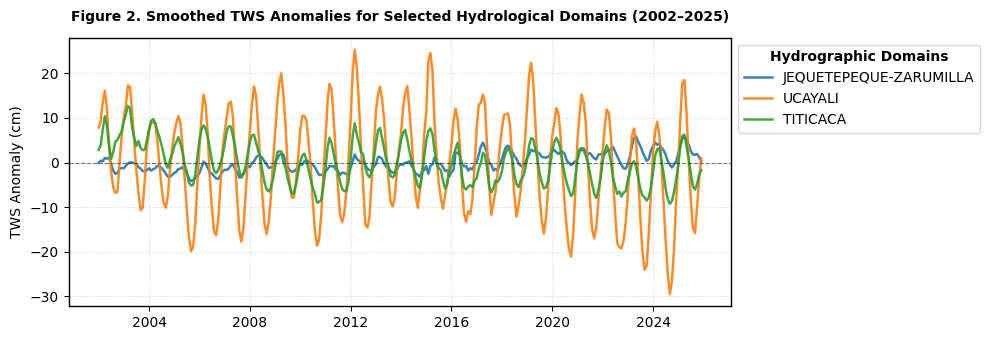

In [13]:
# ── Domain selection for preview plot ────────────────────────────────────────

# Modify this list to visualise any subset of the 14 domains.
# ------------------------------------------------------------------
SELECTED_DOMAINS = ['JEQUETEPEQUE-ZARUMILLA', 'UCAYALI', 'TITICACA']
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 3.5))

for domain in SELECTED_DOMAINS:
    if domain in df_tws_final.columns:
        ax.plot(df_tws_final.index, df_tws_final[domain],
                label=domain, linewidth=1.8, alpha=0.9)
    else:
        print(f"[WARNING] Domain '{domain}' not found. Available: {list(df_tws_final.columns)}")

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title(
    'Figure 2. Smoothed TWS Anomalies for Selected Hydrological Domains (2002–2025)',
    fontweight='bold', pad=12
)
ax.set_ylabel('TWS Anomaly (cm)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1),
          title='Hydrographic Domains', title_fontproperties={'weight': 'bold'})
ax.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


### 📊 Section III — Results Summary

**Spatial Clipping:** All 14 domains were successfully clipped from the GRACE raster. Domains with fragmented geometries were handled by selecting the largest polygon.

**Time Series Shape:** The resulting DataFrame contains monthly time steps (2002–2025) × 14 domain columns. The 3-month centred smoothing introduces NaN values in the first and last month positions, handled in Section IV.

**Preview Interpretation:** The three selected domains exhibit contrasting seasonal amplitudes consistent with their macro-basin type. UCAYALI (Atlantic/Amazon) shows the largest amplitude, reflecting the intense seasonal precipitation cycle of the Amazon basin. TITICACA shows an intermediate amplitude, while JEQUETEPEQUE-ZARUMILLA (Pacific) displays the lowest amplitude, consistent with the semi-arid conditions of the Peruvian coast. This pattern holds broadly across all 14 domains: Amazonian basins tend to have the highest TWS variability and coastal basins the lowest.


# IV. Temporal Signal Decomposition

In hydrology, the Terrestrial Water Storage ($TWS$) signal can be modelled as a sum of three additive components:

$$TWS(t) = \text{Trend}(t) + \text{Seasonal}(t) + \text{Residual}(t)$$

Separating these components allows us to:
- Quantify **long-term trends** (e.g., groundwater depletion, glacier retreat),
- Characterise the **regular seasonal cycle** (recharge/discharge driven by precipitation), and
- Isolate the **residual/anomaly signal** that encodes extreme events such as El Niño and La Niña episodes.

The decomposition uses the classical **additive model** (`statsmodels.seasonal_decompose`) with a 12-month period and `extrapolate_trend='freq'` to avoid edge NaN artefacts.


## 4.1. Additive Decomposition (All 14 Domains)

The decomposition is applied iteratively to all 14 domain time series. NaN values introduced by the 3-month smoothing are dropped prior to decomposition.


In [14]:
# ── Drop smoothing-edge NaNs before decomposition ────────────────────────────
df_tws_clean = df_tws_final.dropna()
print(f"Clean time series length: {len(df_tws_clean)} months "
      f"({df_tws_clean.index[0].date()} → {df_tws_clean.index[-1].date()})")

# ── Additive decomposition for all 14 domains ─────────────────────────────────
dict_trend    = {}
dict_seasonal = {}
dict_resid    = {}

for domain in df_tws_clean.columns:
    result = seasonal_decompose(
        df_tws_clean[domain],
        model='additive',
        period=12,                   # 12-month annual cycle
        extrapolate_trend='freq'     # frequency-domain trend extrapolation at edges
    )
    dict_trend[domain]    = result.trend
    dict_seasonal[domain] = result.seasonal
    dict_resid[domain]    = result.resid

df_trend    = pd.DataFrame(dict_trend)
df_seasonal = pd.DataFrame(dict_seasonal)
df_residual = pd.DataFrame(dict_resid)

# Deseasonalized = Original − Seasonal (used as primary input for ENSO correlation)
df_deseasonalized = df_tws_final - df_seasonal

print("✓ Additive decomposition completed for all 14 domains.")


Clean time series length: 288 months (2002-01-01 → 2025-12-01)
✓ Additive decomposition completed for all 14 domains.


## 4.2. Deseasonalized Signal — Trend + Residual Component

Removing the seasonal component exposes the lower-frequency TWS variability dominated by inter-annual climate forcing (e.g., ENSO) and multi-year trends. This signal is the primary input for all ENSO teleconnection analyses in Sections V–VII.


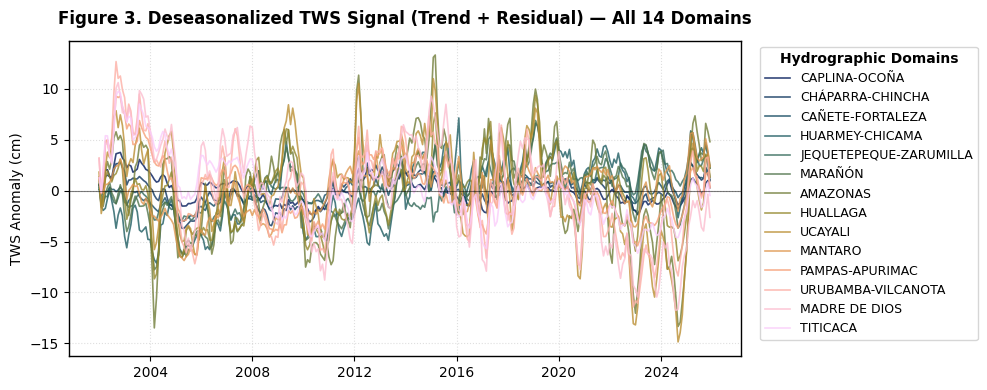

In [15]:
# ── Deseasonalized signal visualisation (all 14 domains) ─────────────────────
batlow = cmc.batlow(np.linspace(0, 1, 14))

fig, ax = plt.subplots(figsize=(10, 4))
for i, domain in enumerate(df_deseasonalized.columns):
    ax.plot(df_deseasonalized.index, df_deseasonalized[domain],
            label=domain, color=batlow[i], linewidth=1.2, alpha=0.8)

ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_title('Figure 3. Deseasonalized TWS Signal (Trend + Residual) — All 14 Domains',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('TWS Anomaly (cm)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
          title='Hydrographic Domains', fontsize=9,
          title_fontproperties={'weight': 'bold'})
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()


## 4.3. Pairwise Correlation Matrix of Deseasonalized TWS

The pair grid below quantifies inter-domain synchronisation after seasonal removal:
- **Upper triangle:** Pearson r coefficient coloured by magnitude and sign (Vik colormap).
- **Diagonal:** KDE distribution of each domain's deseasonalized signal.
- **Lower triangle:** Scatter plot with regression line.

Domain axes use the numeric labels 1–14 defined in `REGION_ORDER` (Section 2.5).


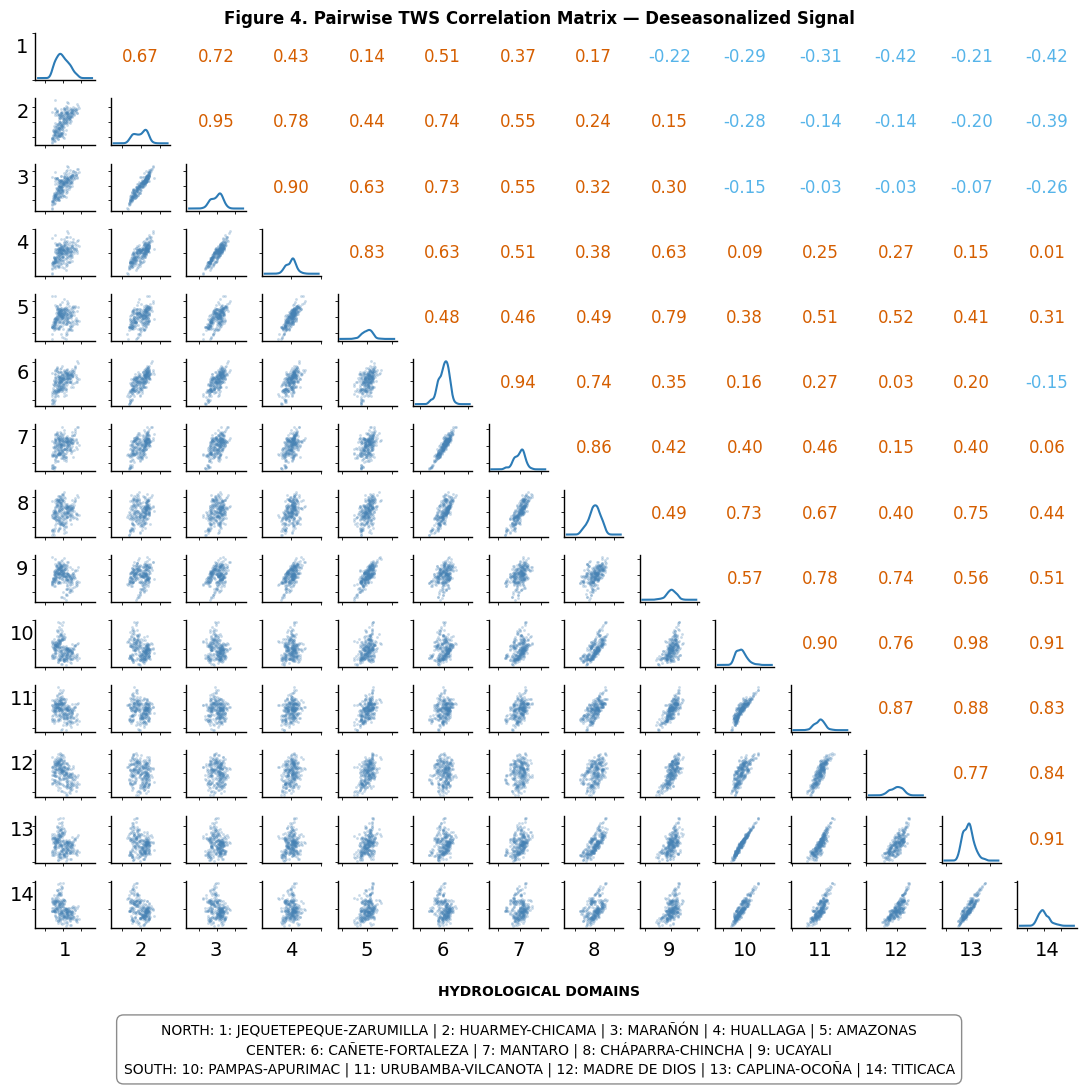

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Domain order and numeric labels from REGION_ORDER ────────────────────────
name_to_number = {
    label.upper(): idx
    for idx, (code, label) in enumerate(REGION_ORDER, start=1)
}

ORDERED_DOMAINS = [
    'JEQUETEPEQUE-ZARUMILLA', 'HUARMEY-CHICAMA',
    'MARAÑÓN',                'HUALLAGA',        'AMAZONAS',
    'CAÑETE-FORTALEZA',       'MANTARO',         'CHÁPARRA-CHINCHA',
    'UCAYALI',
    'PAMPAS-APURIMAC',        'URUBAMBA-VILCANOTA', 'MADRE DE DIOS',
    'CAPLINA-OCOÑA',          'TITICACA',
]
available = [d for d in ORDERED_DOMAINS if d in df_deseasonalized.columns]
df_ordered = df_deseasonalized[available].dropna()

# Rename columns to their assigned numbers for display
df_plot = df_ordered.rename(columns=lambda col: name_to_number.get(col, col))

# ── Helper functions ──────────────────────────────────────────────────────────
def plot_corr_coef(x, y, **kwargs):
    ax = plt.gca()
    r, _ = stats.pearsonr(x.dropna(), y.dropna())
    color = '#D55E00' if r >= 0 else '#56B4E9'
    ax.text(0.5, 0.5, f'{r:.2f}',
            transform=ax.transAxes,
            ha='center', va='center',
            fontsize=12, color=color)
    ax.set_axis_off() # Hide all axis elements for text-only cells

def diag_kde(x, **kwargs):
    ax = plt.gca()
    x.plot.kde(ax=ax, color='#2c7bb6', linewidth=1.5)
    ax.set_ylabel('') # Keep this for density plot-specific label handling
    # Hide axis lines (spines)
    for spine in ax.spines.values():
        spine.set_visible(False)

def plot_scatter(x, y, **kwargs):
    ax = plt.gca()
    ax.scatter(x, y, alpha=0.3, s=4, color='steelblue', linewidths=0)

# ── Build PairGrid ────────────────────────────────────────────────────────────

g = sns.PairGrid(df_plot, height=0.8, aspect=1.0) # Increased height for unrotated labels
g.map_upper(plot_corr_coef) # Coefficients in upper triangle
g.map_diag(diag_kde)
g.map_lower(plot_scatter)   # Scatter plots in lower triangle

# Loop through all axes to explicitly remove ticks and inner labels
n_rows, n_cols = g.axes.shape
for i in range(n_rows):
    for j in range(n_cols):
        ax = g.axes[i, j]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

# Show all 14 numbers on the bottom row and left column only
# These loops re-add the desired outer labels after cleaning all axes
n = len(df_plot.columns)
for j, ax in enumerate(g.axes[-1, :]): # Bottom row for x-labels
    ax.set_xlabel(str(j + 1), fontsize=14, rotation=0)
for i, ax in enumerate(g.axes[:, 0]): # Left column for y-labels
    ax.set_ylabel(str(i + 1), fontsize=14, rotation=0)

# ── Legend at the bottom ──────────────────────────────────────────────────────
north  = [f"{i+1}: {ORDERED_DOMAINS[i]}" for i in range(5)]
center = [f"{i+1}: {ORDERED_DOMAINS[i]}" for i in range(5, 9)]
south  = [f"{i+1}: {ORDERED_DOMAINS[i]}" for i in range(9, 14)]
legend_str = (
    "NORTH: "  + " | ".join(north)  + "\n" +
    "CENTER: " + " | ".join(center) + "\n" +
    "SOUTH: "  + " | ".join(south)
)

# Add 'LEGEND' title
plt.figtext(0.5, 0.12, "HYDROLOGICAL DOMAINS", ha="center", fontsize=10, fontweight='bold', color='black')

# Adjusted y coordinate for figtext to place it slightly above the bottom edge
plt.figtext(0.5, 0.05, legend_str, ha="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='gray'))
# Increased bottom margin to accommodate the legend
plt.subplots_adjust(bottom=0.18)

g.figure.suptitle(
    'Figure 4. Pairwise TWS Correlation Matrix — Deseasonalized Signal',
    fontsize=12, fontweight='bold', y=1.0)

# Removed plt.tight_layout() to prevent it from overriding manual adjustments
plt.show()
plt.close()

## 4.4. Annual Seasonal Cycle by Natural Region

The seasonal component captures the deterministic annual cycle of TWS recharge and discharge. A single representative year (2010) is selected to display the phase and amplitude of this cycle for each domain, grouped by natural region (Coast, Andes, Amazon). The line style encodes the natural region:
- `--` dashed: **Pacific/Coastal** domains
- `-` solid: **Andean** domains
- `:` dotted: **Amazonian** domains


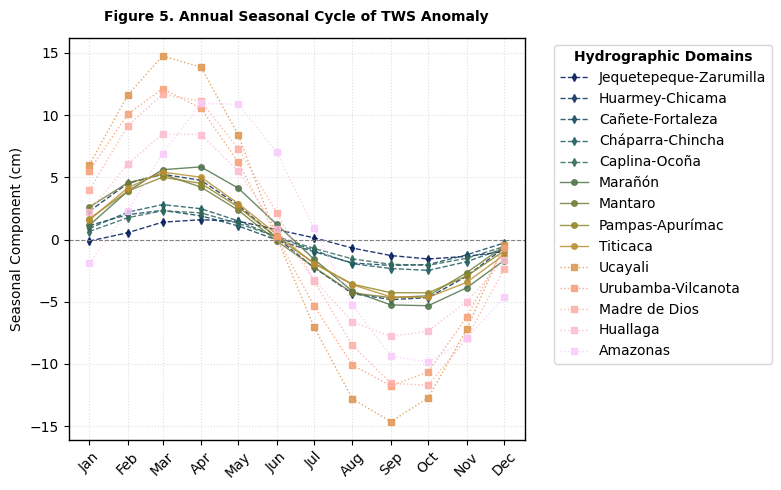

In [24]:
# ── Seasonal climatology — representative year ────────────────────────────────
YEAR_TO_PLOT = '2010'
seasonal_year = df_seasonal.loc[YEAR_TO_PLOT]

# Domain configuration: (DataFrame column, legend label, Batlow index, linestyle, marker)
REGIONS_CONFIG = [
    # Pacific / Coastal
    ('JEQUETEPEQUE-ZARUMILLA', 'Jequetepeque-Zarumilla', 0,  '--', 'd'),
    ('HUARMEY-CHICAMA',        'Huarmey-Chicama',         1,  '--', 'd'),
    ('CAÑETE-FORTALEZA',       'Cañete-Fortaleza',        2,  '--', 'd'),
    ('CHÁPARRA-CHINCHA',       'Cháparra-Chincha',        3,  '--', 'd'),
    ('CAPLINA-OCOÑA',          'Caplina-Ocoña',           4,  '--', 'd'),
    # Andean Highlands
    ('MARAÑÓN',                'Marañón',                 5,  '-',  'o'),
    ('MANTARO',                'Mantaro',                 6,  '-',  'o'),
    ('PAMPAS-APURIMAC',        'Pampas-Apurímac',         7,  '-',  'o'),
    ('TITICACA',               'Titicaca',                8,  '-',  'o'),
    # Amazonian
    ('UCAYALI',                'Ucayali',                 9,  ':',  's'),
    ('URUBAMBA-VILCANOTA',     'Urubamba-Vilcanota',      10, ':',  's'),
    ('MADRE DE DIOS',          'Madre de Dios',           11, ':',  's'),
    ('HUALLAGA',               'Huallaga',                12, ':',  's'),
    ('AMAZONAS',               'Amazonas',                13, ':',  's'),
]
batlow = cmc.batlow(np.linspace(0, 1, 14))

fig, ax = plt.subplots(figsize=(8, 5))
for df_col, legend_lbl, c_idx, lstyle, mstyle in REGIONS_CONFIG:
    if df_col in seasonal_year.columns:
        ax.plot(seasonal_year.index, seasonal_year[df_col],
                label=legend_lbl, color=batlow[c_idx],
                linestyle=lstyle, marker=mstyle, markersize=4, alpha=0.85)
    else:
        print(f"[WARNING] Column '{df_col}' not found in df_seasonal.")

ax.set_xticks(seasonal_year.index)
ax.set_xticklabels(seasonal_year.index.strftime('%b'), rotation=45, fontsize=10)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title(f'Figure 5. Annual Seasonal Cycle of TWS Anomaly',
             fontweight='bold', pad=12)
ax.set_ylabel('Seasonal Component (cm)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          title='Hydrographic Domains', title_fontproperties={'weight': 'bold'})
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()


### 📊 Section IV — Results Summary

**Deseasonalized Signal (Figure 3):** Once the seasonal cycle is removed, inter-annual variability emerges clearly. Notable drought episodes appear as synchronised negative anomalies across multiple domains, while the El Niño  2017 Coastal El Niño is visible as a localised positive spike in northern coastal domains. The Titicaca domain shows a distinct multi-year drying trend.

**Correlation Matrix (Figure 4):** Strong positive correlations (r > 0.7) are observed among Central and North Amazonian domains, confirming their shared atmospheric teleconnection pattern. Pacific coastal domains cluster separately with weaker internal correlations, reflecting the higher heterogeneity of coastal hydrology. Negative or near-zero correlations between some coastal and Amazonian domains suggest opposing responses to ENSO forcing—this will be explored quantitatively in Section VI.

**Seasonal Cycle (Figure 5):** Amazonian domains (Ucayali, Madre de Dios, Huallaga, Amazonas) exhibit the highest seasonal amplitude (~ 15–25 cm), with TWS maxima in March–April (peak of the austral wet season) and minima in September–October. Andean domains (Mantaro, Pampas-Apurímac, Titicaca) show intermediate amplitudes (~ 5–15 cm) with a similar phase. Pacific/Coastal domains display minimal seasonal variation (< 5 cm), consistent with their semi-arid to hyper-arid climatology.


# V. ONI and ICEN Teleconnections

This section integrates the ENSO climate indices with the domain-level TWS signal to visualise and diagnose the spatiotemporal footprint of El Niño and La Niña events across Peru. Two complementary indices are used:

- **ONI (Oceanic Niño Index):** 3-month running mean of SST anomalies in the Niño 3.4 region (Central-Eastern Pacific). Standard threshold: ≥ +0.5°C (El Niño) / ≤ −0.5°C (La Niña).
- **ICEN (Índice Costero El Niño):** SST anomaly in the Niño 1+2 region off the Peruvian coast. Captures the *Coastal El Niño*, which directly forces precipitation anomalies over the Pacific slope of the Andes. Threshold: ≥ +0.4°C / ≤ −0.7°C.


## 5.1. Loading ENSO Indices (ONI and ICEN)

Both indices are stored as CSV files in the repository (`data/enso/`), pre-processed to match the GRACE temporal domain (2002–2025) with monthly resolution and a `time` index column in `YYYY-MM-DD` format.


In [ ]:
# ── File paths ────────────────────────────────────────────────────────────────
ONI_PATH  = os.path.join(REPO_NAME, "data/enso/oni_2002_2025.csv")
ICEN_PATH = os.path.join(REPO_NAME, "data/enso/icen_2002_2025.csv")

# ── Load ONI ──────────────────────────────────────────────────────────────────
if os.path.exists(ONI_PATH):
    df_oni = pd.read_csv(ONI_PATH, index_col='time', parse_dates=True)
    print(f"✓ ONI loaded  | {len(df_oni)} months | Columns: {list(df_oni.columns)}")
else:
    raise FileNotFoundError(f"ONI file not found at '{ONI_PATH}'.")

# ── Load ICEN ─────────────────────────────────────────────────────────────────
if os.path.exists(ICEN_PATH):
    df_icen = pd.read_csv(ICEN_PATH, index_col='time', parse_dates=True)
    print(f"✓ ICEN loaded | {len(df_icen)} months | Columns: {list(df_icen.columns)}")
else:
    raise FileNotFoundError(f"ICEN file not found at '{ICEN_PATH}'.")

print("── ONI (first 3 rows) ──")
print(df_oni.head(3).to_string())
print("── ICEN (first 3 rows) ──")
print(df_icen.head(3).to_string())


## 5.2. Spatiotemporal Evolution: Hovmöller Diagram

The multi-panel figure combines three panels:
- **Panel A (ONI):** Central-Pacific forcing timeline with warm/cold event shading.
- **Panel B (ICEN):** Coastal-Pacific forcing timeline with distinct thresholds.
- **Panel C (TWS Hovmöller):** Deseasonalized TWS anomalies arranged latitudinally (North → South), enabling direct visual association between oceanic forcing and hydrological response.

Domains are ordered into three latitudinal blocks separated by horizontal lines: North, Central, and South.


/tmp/ipykernel_4988/3566973676.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


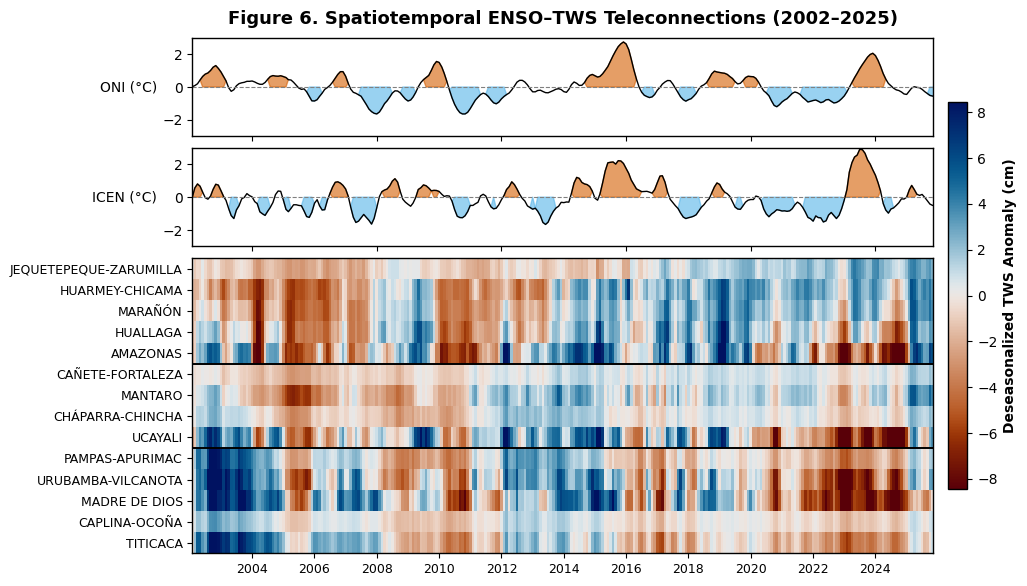

In [26]:
# ── Domain ordering: North-to-South latitudinal blocks ───────────────────────
ordered_domain_names = [
    # North Block — Equatorial / Coastal El Niño influence
    'JEQUETEPEQUE-ZARUMILLA', 'HUARMEY-CHICAMA', 'MARAÑÓN', 'HUALLAGA', 'AMAZONAS',
    # Central Block — Andean transition zone
    'CAÑETE-FORTALEZA', 'MANTARO', 'CHÁPARRA-CHINCHA', 'UCAYALI',
    # South Block — High spatial coherence / Global ENSO droughts
    'PAMPAS-APURIMAC', 'URUBAMBA-VILCANOTA', 'MADRE DE DIOS', 'CAPLINA-OCOÑA', 'TITICACA',
]

# Filter to available domains and build ordered DataFrame
avail_hov = [d for d in ordered_domain_names if d in df_deseasonalized.columns]
df_deseasonalized_ordered = df_deseasonalized[avail_hov]

# Matrix for pcolormesh
data_matrix = df_deseasonalized_ordered.T.values
fechas_tws  = df_deseasonalized_ordered.index
dominios    = df_deseasonalized_ordered.columns

# Symmetric colour limits (98th percentile avoids outlier stretching)
vmax = np.nanpercentile(np.abs(data_matrix), 98)
vmin = -vmax

# ── Multi-panel figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
gs  = gridspec.GridSpec(5, 1, height_ratios=[1, 1, 3, 0, 0], hspace=0.12)

ax_oni  = fig.add_subplot(gs[0])
ax_icen = fig.add_subplot(gs[1])
ax_tws  = fig.add_subplot(gs[2])

# Panel A: ONI
ax_oni.plot(df_oni.index, df_oni['oni'], color='black', linewidth=1)
ax_oni.fill_between(df_oni.index, df_oni['oni'], 0,
                    where=(df_oni['oni'] >= 0.5),  color='#D55E00', alpha=0.6, interpolate=True)
ax_oni.fill_between(df_oni.index, df_oni['oni'], 0,
                    where=(df_oni['oni'] <= -0.5), color='#56B4E9', alpha=0.6, interpolate=True)
ax_oni.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_oni.set_ylabel('ONI (°C)', rotation=0, ha='right', va='center', fontsize=10)
ax_oni.set_ylim(-3, 3)
ax_oni.tick_params(axis='x', labelbottom=False)
ax_oni.set_title('Figure 6. Spatiotemporal ENSO–TWS Teleconnections (2002–2025)',
                 fontsize=13, fontweight='bold', pad=10)

# Panel B: ICEN
ax_icen.plot(df_icen.index, df_icen['icen'], color='black', linewidth=1)
ax_icen.fill_between(df_icen.index, df_icen['icen'], 0,
                     where=(df_icen['icen'] >= 0.4),  color='#D55E00', alpha=0.6, interpolate=True)
ax_icen.fill_between(df_icen.index, df_icen['icen'], 0,
                     where=(df_icen['icen'] <= -0.7), color='#56B4E9', alpha=0.6, interpolate=True)
ax_icen.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_icen.set_ylabel('ICEN (°C)', rotation=0, ha='right', va='center', fontsize=10)
ax_icen.set_ylim(-3, 3)
ax_icen.tick_params(axis='x', labelbottom=False)

# Panel C: TWS Hovmöller
mesh = ax_tws.pcolormesh(fechas_tws, np.arange(len(dominios)), data_matrix,
                         cmap=cmc.vik_r, vmin=vmin, vmax=vmax, shading='nearest')
ax_tws.set_yticks(np.arange(len(dominios)))
ax_tws.set_yticklabels(dominios, fontsize=9)
ax_tws.invert_yaxis()
ax_tws.axhline(4.5, color='black', linewidth=1.4, linestyle='-')   # North / Central
ax_tws.axhline(8.5, color='black', linewidth=1.4, linestyle='-')   # Central / South

# Temporal alignment
START, END = pd.to_datetime('2002-02-01'), pd.to_datetime('2025-11-01')
for ax in [ax_oni, ax_icen, ax_tws]:
    ax.set_xlim(START, END)
ax_tws.xaxis.set_major_locator(mdates.YearLocator(2))
ax_tws.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax_tws.xaxis.get_majorticklabels(), fontsize=9)

cbar = fig.colorbar(mesh, ax=[ax_oni, ax_icen, ax_tws],
                    orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('Deseasonalized TWS Anomaly (cm)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()


## 5.3. Inter-Domain TLCC Matrix

For a selected reference domain, the Pearson cross-correlation is computed against all other domains across a lag range of [−MAX_LAG, +MAX_LAG] months. This identifies the direction and timing of TWS signal propagation across the Peruvian territory relative to a given headwater or coastal domain.

**Lag convention:**
- Negative lag → target domain **leads** the reference
- Positive lag → target domain **lags** the reference


Reference domain : HUARMEY-CHICAMA
Lag range        : ±12 months


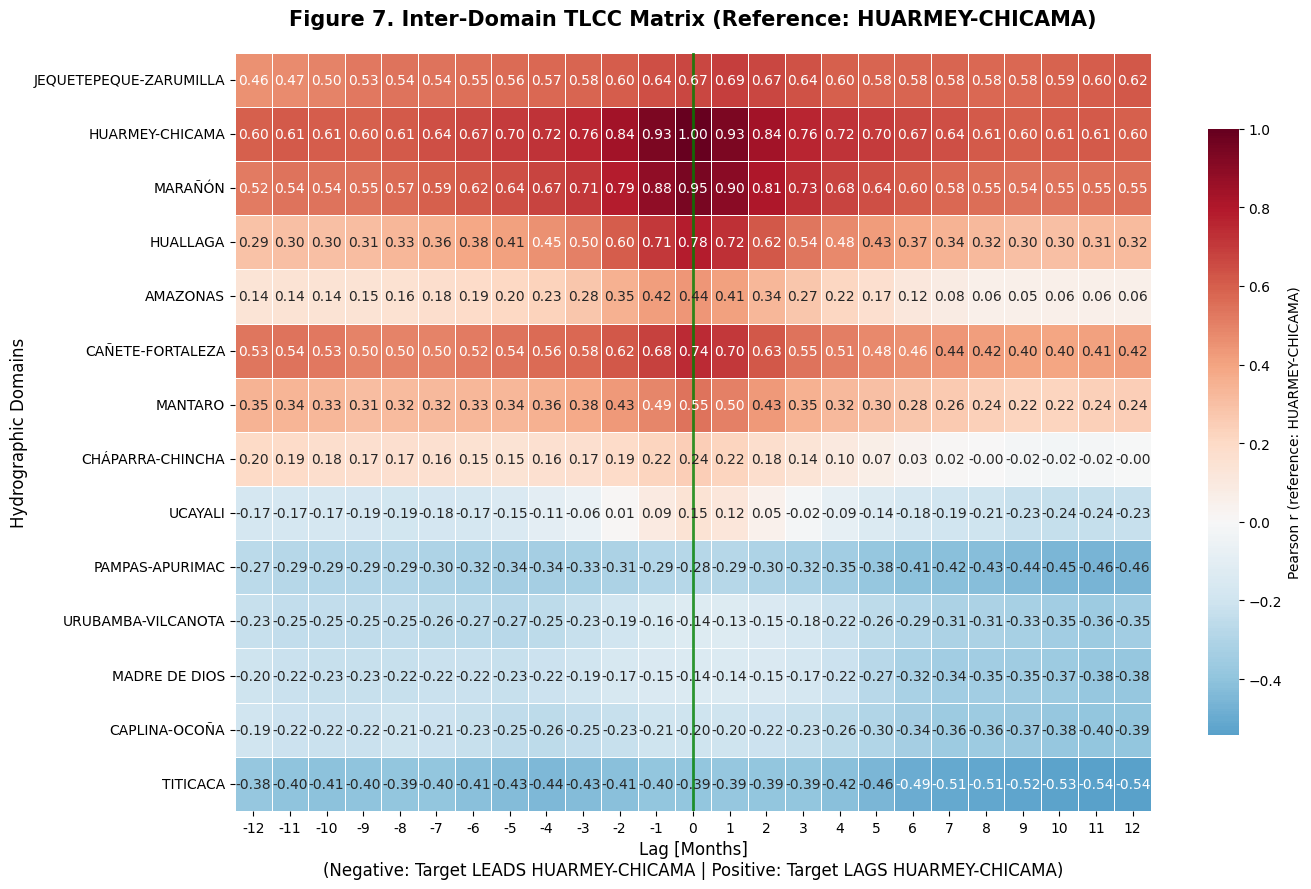

In [28]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Change REFERENCE_DOMAIN to explore propagation from different starting points.
# Suggested options: 'MARAÑÓN', 'MANTARO', 'HUALLAGA', 'PAMPAS-APURIMAC',
#                    'URUBAMBA-VILCANOTA', 'CAÑETE-FORTALEZA'
REFERENCE_DOMAIN = 'HUARMEY-CHICAMA'
MAX_LAG = 12  # Range of +/- 12 months

# ── TLCC function ─────────────────────────────────────────────────────────────
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# ── Compute TLCC for all domains against the reference ────────────────────────
print(f"Reference domain : {REFERENCE_DOMAIN}")
print(f"Lag range        : ±{MAX_LAG} months")

tlcc_results = {}
for domain in ordered_domain_names:
    tlcc_results[domain] = compute_tlcc(df_deseasonalized_ordered[REFERENCE_DOMAIN],
                                        df_deseasonalized_ordered[domain],
                                        MAX_LAG)

df_tlcc_matrix = pd.DataFrame(tlcc_results).T

# ── TLCC Heatmap ──────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': f'Pearson r (reference: {REFERENCE_DOMAIN})', 'shrink': 0.8})

plt.title(f'Figure 7. Inter-Domain TLCC Matrix (Reference: {REFERENCE_DOMAIN})',
          fontweight='bold', fontsize=15, pad=20)
plt.xlabel(f'Lag [Months]\n(Negative: Target LEADS {REFERENCE_DOMAIN} | Positive: Target LAGS {REFERENCE_DOMAIN})',
           fontsize=12)
plt.ylabel('Hydrographic Domains', fontsize=12)

plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

## 5.4. Peak Correlation and Response Lag by Domain

For each domain, we extract the lag at which the cross-correlation with the reference domain reaches its absolute maximum. The resulting bar chart provides a compact summary of the response timing across the latitudinal gradient.


/tmp/ipykernel_4988/3726334394.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_peaks.index, rotation=45, ha='right')


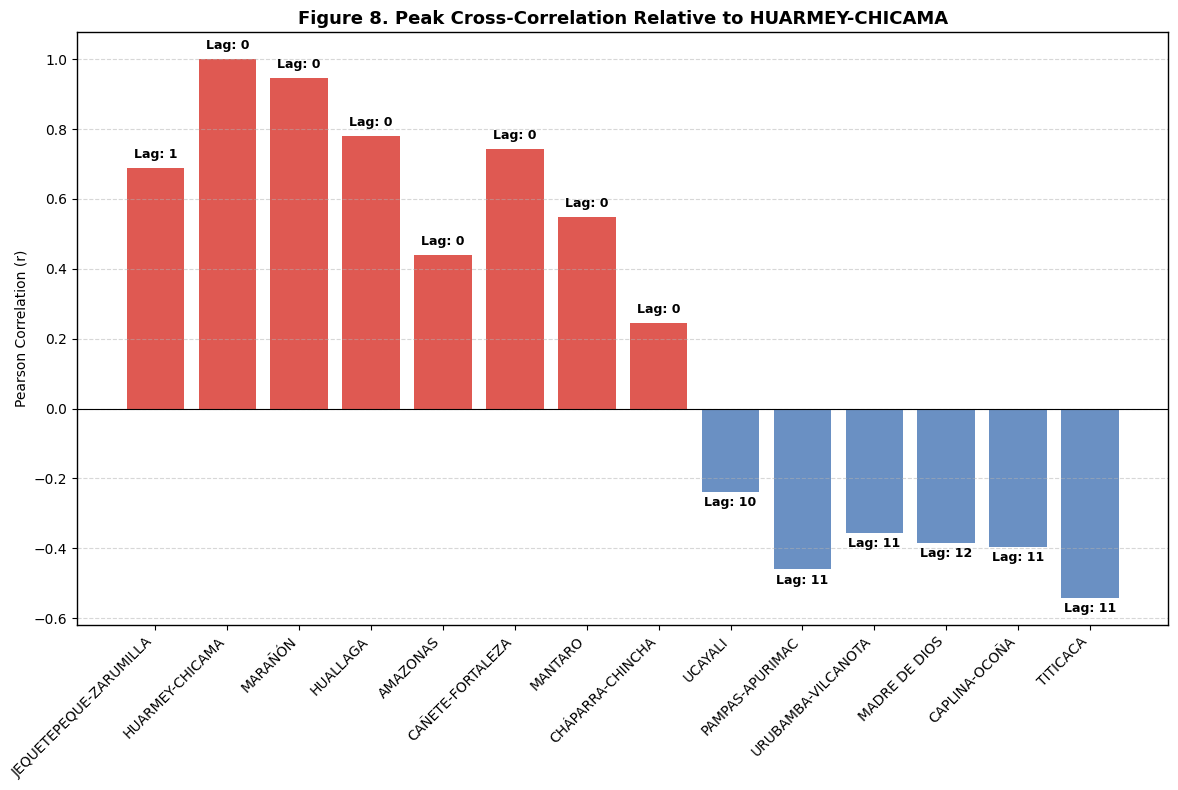

In [31]:
# ── Extract peak correlation and corresponding lag for each domain ────────────
# Restore original domain names as index for extraction
df_tlcc_named = pd.DataFrame(tlcc_results).T   # rows = domain names

peak_lags = []
max_corrs = []

for domain in avail_hov:
    abs_corr = df_tlcc_named.loc[domain].abs()
    peak_lag = abs_corr.idxmax()
    max_val  = df_tlcc_named.loc[domain, peak_lag]
    peak_lags.append(peak_lag)
    max_corrs.append(max_val)

df_peaks = pd.DataFrame({
    'Domain'          : avail_hov,
    'Max_Correlation' : max_corrs,
    'Lag_Months'      : peak_lags
}).set_index('Domain')

# ── Bar chart of peak correlations with lag annotations ───────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#d73027' if c > 0 else '#4575b4' for c in df_peaks['Max_Correlation']]
bars   = ax.bar(df_peaks.index, df_peaks['Max_Correlation'], color=colors, alpha=0.8)

for bar, lag in zip(bars, df_peaks['Lag_Months']):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            yval + (0.02 if yval > 0 else -0.05),
            f'Lag: {lag}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Figure 8. Peak Cross-Correlation Relative to {REFERENCE_DOMAIN}',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Pearson Correlation (r)')
ax.set_xticklabels(df_peaks.index, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


## 5.5. Deseasonalized TWS (2015–2019 Focus Window)

This plot zooms into the 2015–2019 period to visualise clusters or the latitudinal gradient of the TWS response during the 2015–2016 canonical El Niño and the 2017 Coastal El Niño events.


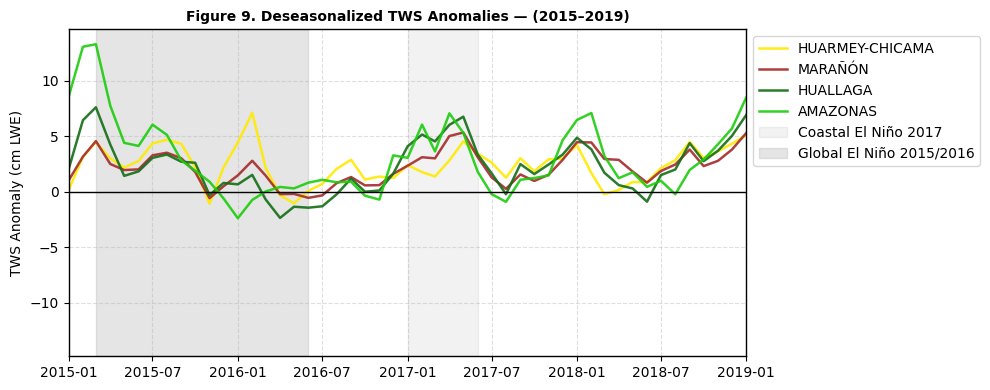

In [ ]:
# ── Domains group ──────────────────────────────────────
GROUP_DOMAINS = ['HUARMEY-CHICAMA','MARAÑÓN','HUALLAGA', 'AMAZONAS']
GROUP_COLORS  = ['#FFEA00', '#A52A2A', '#136d15', '#1dcc0d']

## Tonos verde: ['#136d15', '#41980a', '#1dcc0d','#67ff62','#a9ce21']
## Tonos rojo/marrón: ['#A52A2A', '#CD5C5C', '#F08080', '#FA8072']
## Tonos amarillo: ['#FFFF00', '#FFEA00', '#FFD700', '#FFAB00', '#FFC107']

fig, ax = plt.subplots(figsize=(10, 4))

for domain, color in zip(GROUP_DOMAINS, GROUP_COLORS):
    if domain in df_deseasonalized_ordered.columns:
        ax.plot(df_deseasonalized_ordered.index,
                df_deseasonalized_ordered[domain],
                label=domain, color=color, linewidth=1.8, alpha=0.9)

ax.axhline(0, color='black', linewidth=1.0, linestyle='-')

ax.axvspan(pd.Timestamp('2017-01-01'), pd.Timestamp('2017-06-01'),
           color='gray', alpha=0.1, label='Coastal El Niño 2017')

ax.axvspan(pd.Timestamp('2015-03-01'), pd.Timestamp('2016-06-01'),
           color='gray', alpha=0.2, label='Global El Niño 2015/2016')

# Zoom to the key ENSO event window
ax.set_xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2019-01-01'))
ax.set_title('Figure 9. Deseasonalized TWS Anomalies — (2015–2019)',
             fontweight='bold')
ax.set_ylabel('TWS Anomaly (cm LWE)')
ax.set_xlabel('')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()


### 📊 Section V — Results Summary

**Overview:** The Hovmöller diagram reveals that Peru's deseasonalized TWS signal alternates between three recurring states over the 2002–2025 record: (1) **nationally coherent drought** (all 14 domains simultaneously negative), (2) a **North–South TWS dipole** of varying polarity, and (3) **near-national surplus**. The direction and intensity of the dipole are jointly modulated by the ONI and ICEN, which do not always co-vary.

---

**2002–2005 — Contradictory forcing and dipole emergence:**
A positive ONI and negative ICEN during 2003–2004 produce a North–South dipole: deficit in the northern coastal domains and surplus in the southern Andean block. The Amazonian domains Huallaga and Amazonas track the ICEN signal closely, showing deficit during the negative ICEN phase. When both indices converge to negative in 2005, the dipole collapses into the first nationally coherent drought of the record, with negative TWS anomalies across all 14 domains.

**2006–2009 — Persistent dipole and subtle inversion:**
The North–South dipole (deficit north, surplus south) persists through 2006–2007 under a Niño→Niña transition. Around 2008–2009, the dipole subtly inverts (surplus north, deficit south). Throughout this period, Huallaga and Amazonas continue to track the ICEN signal.

**2010–2013 — Generalised drought and gradual recovery:**
By 2010, both ONI and ICEN converge to negative, producing the second and most spatially homogeneous nationally coherent drought of the record — no compensating surplus is observed in any domain. Recovery is gradual, re-establishing a North–South dipole (deficit north, surplus south) by 2013. Notably, Amazonas and Ucayali display surplus in 2013 despite the ICEN indicating La Niña and the ONI remaining near neutral.

**2014–2017 — Near-national surplus and strongest inverted dipole:**
The 2013 dipole progressively dissolves into near-national surplus during 2014–2015, with weaker positive response at the northern extreme (Jequetepeque-Zarumilla) and southern extremes (Caplina-Ocoña, Titicaca). The 2015–2016 El Niño (ONI > +2°C) drives deficit in the southern and central Andean domains. In 2017, with ONI returning to neutral and ICEN peaking sharply (Coastal El Niño > +2°C), the strongest and most spatially coherent inverted dipole of the record emerges: pronounced surplus in the northern coastal and Amazonian domains simultaneous with clear deficit across the southern block.

**2018–2025 — Persistent inverted dipole with episodic drought pulses:**
The inverted dipole (surplus north, deficit centre–south) consolidates as the dominant state through 2025 — the longest sustained dipole episode in the record. Jequetepeque-Zarumilla displays more pronounced and sustained surplus than in any previous period. The centre–south block fails to recover despite multiple consecutive La Niña years. Three brief episodes of tendency toward generalised deficit interrupt this dominant state: late 2020, early 2023, and early 2025. The strong 2023 El Niño amplifies the northern surplus and deepens the southern deficit, producing the greatest north–south hydrological divergence of the full record. During this period, Amazonas loses its synchrony with the ICEN — registering deficit during the 2023–2024 strong El Niño — while Huallaga and Ucayali maintain a more consistent tracking of the coastal index.

---

**Structural pattern across the full record:**
Nationally coherent drought episodes are more frequent than nationally coherent surplus events over the 2002–2025 period. The dominant dipole polarity across the record is the inverted configuration (surplus north, deficit south), which becomes increasingly persistent after 2017. Among the Amazonian domains, Huallaga and Ucayali show the most consistent synchrony with the ICEN signal throughout the record, while Amazonas exhibits a less stable response that breaks down during strong  El Niño 3.4 events. The differential sensitivity of these adjacent Amazonian basins to ONI vs. ICEN forcing is further examined through the standardised TLCC analysis in Sections VI and VII.

# VI. Climate Forcing: TLCC with Standardised ONI and ICEN Indices

This section quantifies the statistical relationship and temporal delay between oceanic ENSO forcing and terrestrial water storage. The analysis uses **Time-Lagged Cross-Correlation (TLCC)** computed on Z-score standardised signals, enabling direct comparison between TWS (cm) and ENSO indices (°C) across all 14 domains.


## 6.1. Z-Score Standardisation of TWS and ENSO Indices

Standardisation (zero mean, unit variance) ensures that correlation magnitudes reflect true co-variability, not differences in physical units or baseline storage between domains. All signals are standardised independently over the full overlapping period using `sklearn.StandardScaler`.


✓ Standardisation complete.
  ONI/ICEN Z-scores shape : (288, 2)
  TWS Z-scores shape      : (288, 14)


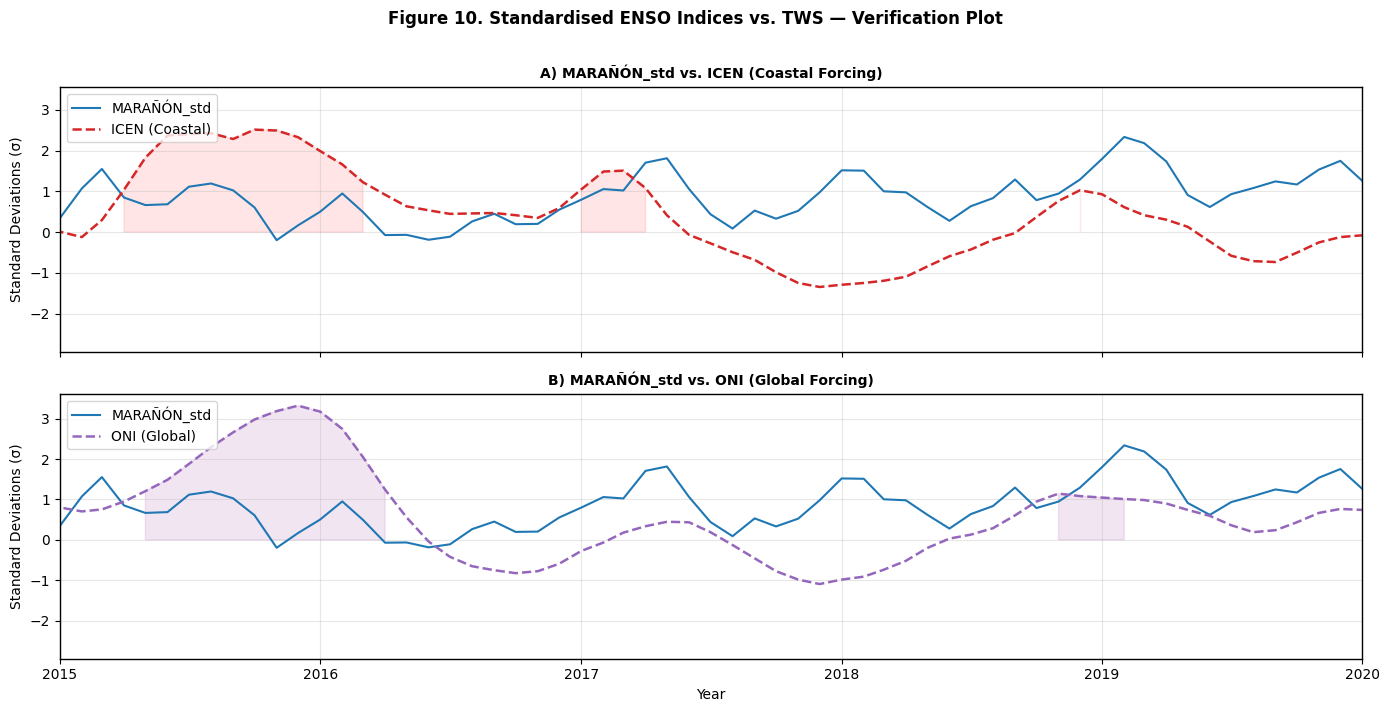

In [32]:
# ── Standardise ENSO indices ──────────────────────────────────────────────────
scaler = StandardScaler()

df_enso_std = pd.DataFrame(index=df_oni.index)
df_enso_std['ONI_std']  = scaler.fit_transform(df_oni[['oni']])
df_enso_std['ICEN_std'] = scaler.fit_transform(df_icen[['icen']])

# ── Standardise deseasonalized TWS for all domains ───────────────────────────
df_tws_std = pd.DataFrame(index=df_deseasonalized_ordered.index)
for domain in df_deseasonalized_ordered.columns:
    series_data = df_deseasonalized_ordered[domain].values.reshape(-1, 1)
    df_tws_std[f"{domain}_std"] = scaler.fit_transform(series_data)

print("✓ Standardisation complete.")
print(f"  ONI/ICEN Z-scores shape : {df_enso_std.shape}")
print(f"  TWS Z-scores shape      : {df_tws_std.shape}")

# ── Verification plot: standardised signals for a representative domain ───────
TARGET_DOMAIN_STD = 'MARAÑÓN_std'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel A: TWS vs ICEN
ax1.plot(df_tws_std.index, df_tws_std[TARGET_DOMAIN_STD],
         label=TARGET_DOMAIN_STD, color='#1f77b4', linewidth=1.5)
ax1.plot(df_enso_std.index, df_enso_std['ICEN_std'],
         label='ICEN (Coastal)', color='#d62728', linewidth=1.8, linestyle='--')
ax1.fill_between(df_enso_std.index, 0, df_enso_std['ICEN_std'],
                 where=(df_enso_std['ICEN_std'] > 1.0), color='red', alpha=0.1)
ax1.set_title(f'A) {TARGET_DOMAIN_STD} vs. ICEN (Coastal Forcing)', fontweight='bold')
ax1.set_ylabel('Standard Deviations (σ)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Panel B: TWS vs ONI
ax2.plot(df_tws_std.index, df_tws_std[TARGET_DOMAIN_STD],
         label=TARGET_DOMAIN_STD, color='#1f77b4', linewidth=1.5)
ax2.plot(df_enso_std.index, df_enso_std['ONI_std'],
         label='ONI (Global)', color='#9467bd', linewidth=1.8, linestyle='--')
ax2.fill_between(df_enso_std.index, 0, df_enso_std['ONI_std'],
                 where=(df_enso_std['ONI_std'] > 1.0), color='purple', alpha=0.1)
ax2.set_title(f'B) {TARGET_DOMAIN_STD} vs. ONI (Global Forcing)', fontweight='bold')
ax2.set_ylabel('Standard Deviations (σ)')
ax2.set_xlabel('Year')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Focus on the key 2015–2020 window
plt.xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2020-01-01'))
plt.suptitle('Figure 10. Standardised ENSO Indices vs. TWS — Verification Plot',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close()


## 6.2. Teleconnection Lag Analysis: Cross-Correlation Functions

For a selected domain, the TLCC is computed against both the ONI and ICEN indices across the lag range [−MAX_LAG, +MAX_LAG] months. Peak correlations and their associated lags are annotated automatically. A positive lag means TWS responds **after** the oceanic forcing, as physically expected.


Reference domain : ONI
Lag range        : ±12 months


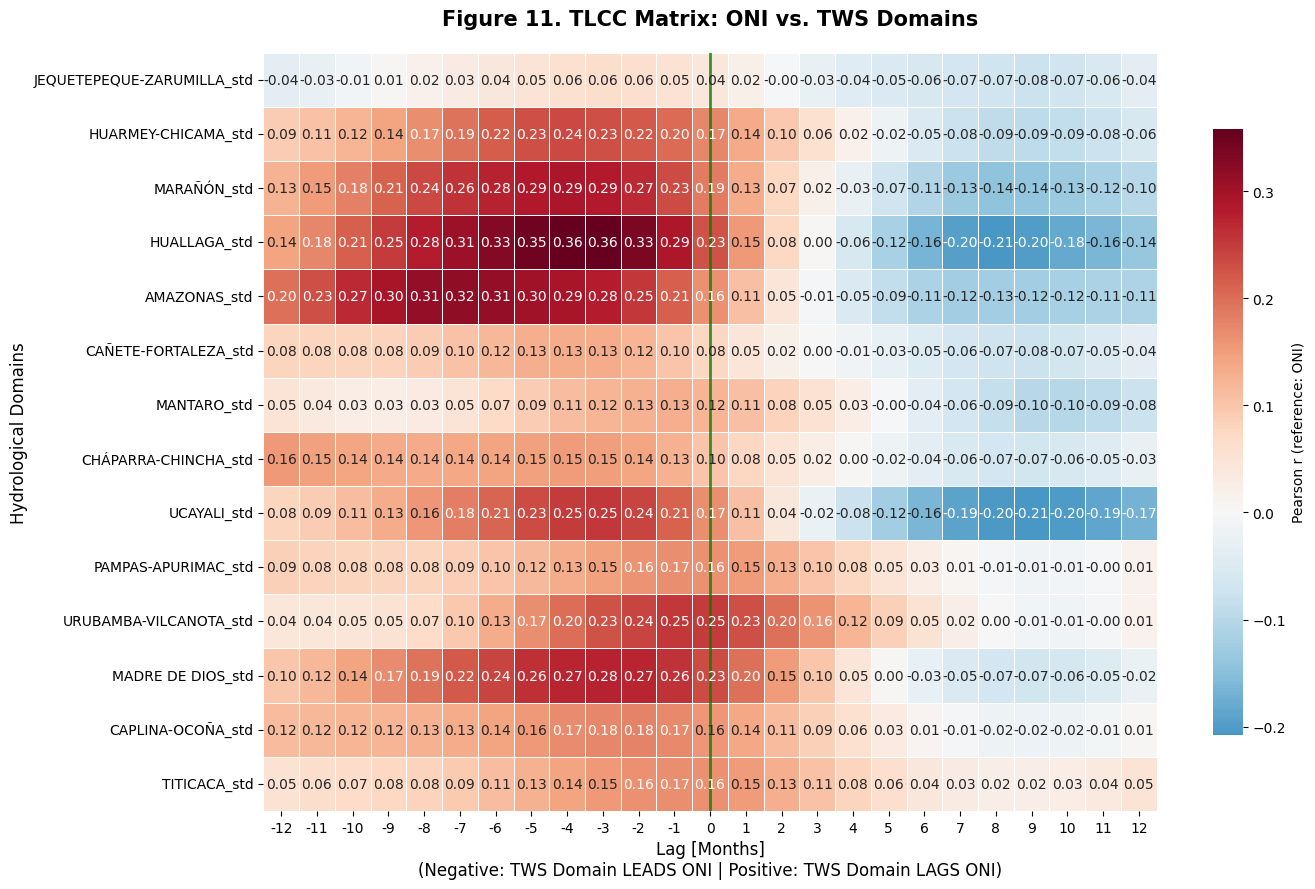

In [34]:
## --- ONI vs. TWS Domains (Standarized)
# ── TLCC function (redefined for self-containment) ───────────────────────────
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# ── Configuration ─────────────────────────────────────────────────────────────
MAX_LAG = 12  # Range of +/- 12 months

# ── Calculation: Correlating ONI_std with all hydrographic domains ──────────
tlcc_oni_results = {}

# Use the already standardized ONI series
onindex_ref_series = df_enso_std['ONI_std']

# ── Compute TLCC for all domains against the reference ────────────────────────
print(f"Reference domain : ONI")
print(f"Lag range        : ±{MAX_LAG} months")

# Iterate through standardized TWS domains
for domain_col_std in df_tws_std.columns:
    target_series = df_tws_std[domain_col_std]
    tlcc_oni_results[domain_col_std] = compute_tlcc(onindex_ref_series, target_series, MAX_LAG)

df_tlcc_oni_matrix = pd.DataFrame(tlcc_oni_results).T

# ── TLCC Heatmap ──────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_oni_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': f'Pearson r (reference: ONI)', 'shrink': 0.8})

plt.title(f'Figure 11. TLCC Matrix: ONI vs. TWS Domains',
          fontweight='bold', fontsize=15, pad=20)
plt.xlabel(f'Lag [Months]\n(Negative: TWS Domain LEADS ONI | Positive: TWS Domain LAGS ONI)',
           fontsize=12)
plt.ylabel('Hydrological Domains', fontsize=12)

plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

Reference domain : ICEN
Lag range        : ±12 months


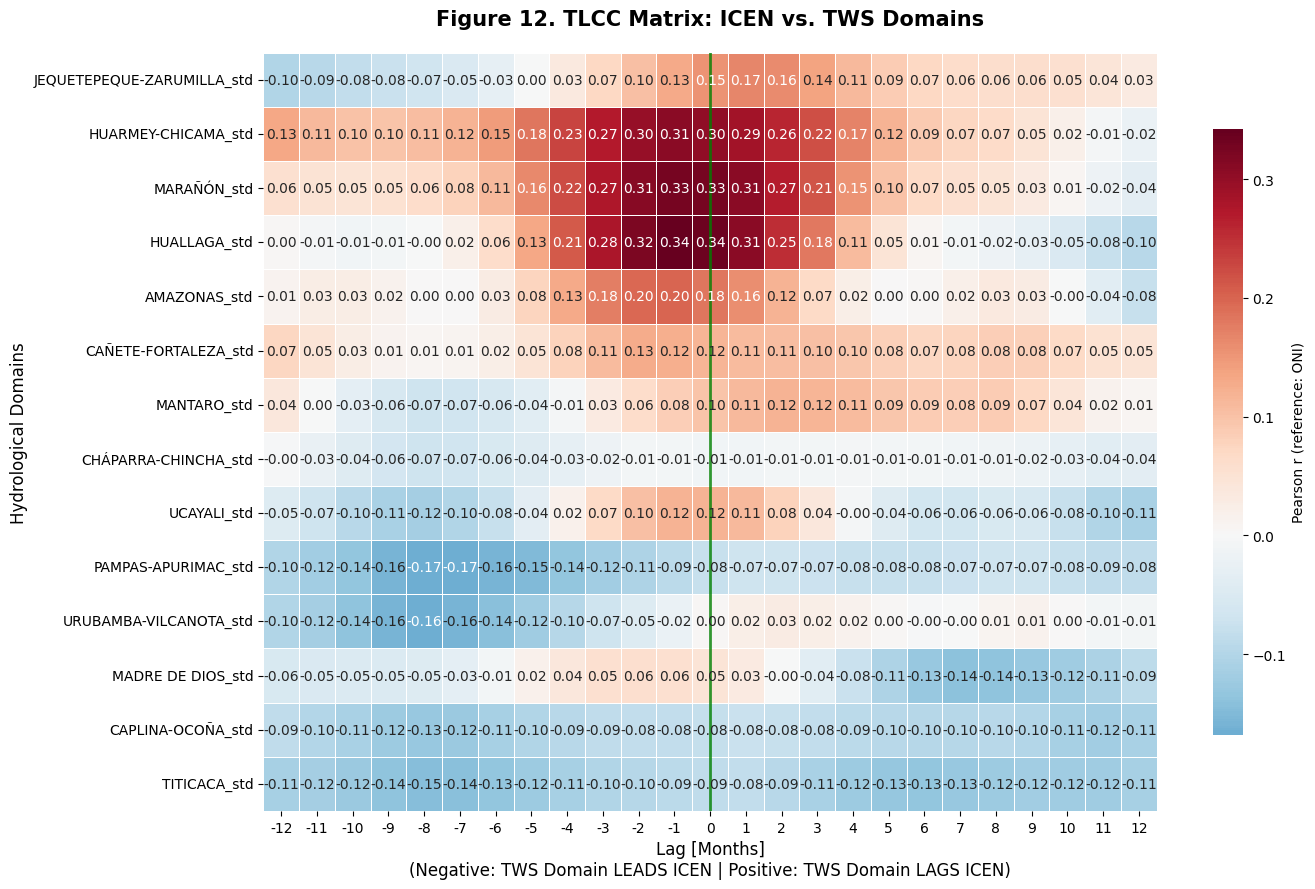

In [36]:
## --- ICEN vs. TWS Domains (Standarized)
# ── TLCC function (redefined for self-containment) ───────────────────────────
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# ── Configuration ─────────────────────────────────────────────────────────────
MAX_LAG = 12  # Range of +/- 12 months

# ── Calculation: Correlating ONI_std with all hydrographic domains ──────────
tlcc_icen_results = {}

# Use the already standardized ONI series
icenindex_ref_series = df_enso_std['ICEN_std']

# ── Compute TLCC for all domains against the reference ────────────────────────
print(f"Reference domain : ICEN")
print(f"Lag range        : ±{MAX_LAG} months")

# Iterate through standardized TWS domains
for domain_col_std in df_tws_std.columns:
    target_series = df_tws_std[domain_col_std]
    tlcc_icen_results[domain_col_std] = compute_tlcc(icenindex_ref_series, target_series, MAX_LAG)


df_tlcc_icen_matrix = pd.DataFrame(tlcc_icen_results).T

# ── TLCC Heatmap ──────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_icen_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': f'Pearson r (reference: ONI)', 'shrink': 0.8})

plt.title(f'Figure 12. TLCC Matrix: ICEN vs. TWS Domains',
          fontweight='bold', fontsize=15, pad=20)
plt.xlabel(f'Lag [Months]\n(Negative: TWS Domain LEADS ICEN | Positive: TWS Domain LAGS ICEN)',
           fontsize=12)
plt.ylabel('Hydrological Domains', fontsize=12)

plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

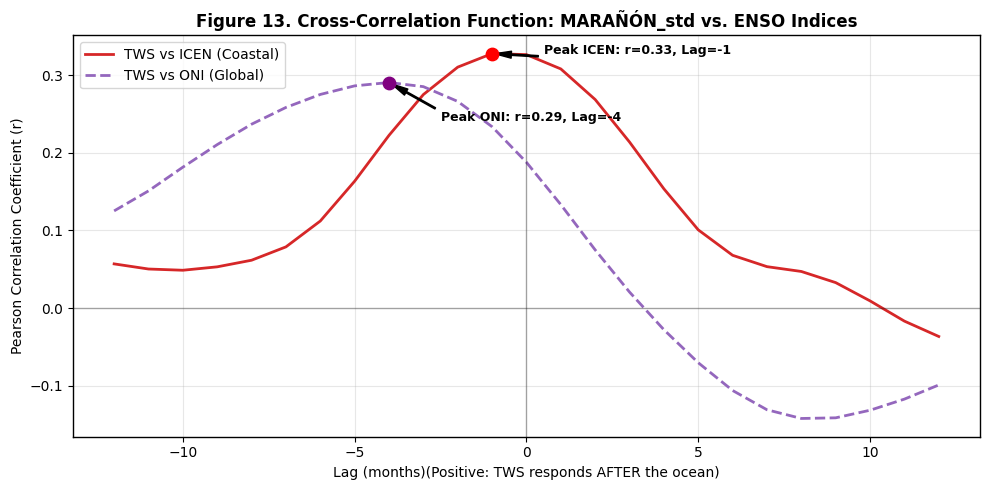

In [37]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Change TARGET_DOMAIN_STD to explore different domains.
TARGET_DOMAIN_STD = 'MARAÑÓN_std'
MAX_LAG           = 12

# ── Compute TLCC for both indices ─────────────────────────────────────────────
tlcc_icen = compute_tlcc(df_enso_std['ICEN_std'], df_tws_std[TARGET_DOMAIN_STD], MAX_LAG)
tlcc_oni  = compute_tlcc(df_enso_std['ONI_std'],  df_tws_std[TARGET_DOMAIN_STD], MAX_LAG)

# ── Cross-correlation function plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(tlcc_icen.index, tlcc_icen.values,
        label='TWS vs ICEN (Coastal)', color='#d62728', linewidth=2.0)
ax.plot(tlcc_oni.index, tlcc_oni.values,
        label='TWS vs ONI (Global)',   color='#9467bd', linewidth=2.0, linestyle='--')

# Annotate ICEN peak
peak_lag_icen  = tlcc_icen.idxmax()
peak_corr_icen = tlcc_icen.max()
ax.scatter(peak_lag_icen, peak_corr_icen, color='red', s=80, zorder=5)
ax.annotate(f'Peak ICEN: r={peak_corr_icen:.2f}, Lag={peak_lag_icen}',
            xy=(peak_lag_icen, peak_corr_icen),
            xytext=(peak_lag_icen + 1.5, peak_corr_icen),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
            fontweight='bold', fontsize=9)

# Annotate ONI peak
peak_lag_oni  = tlcc_oni.idxmax()
peak_corr_oni = tlcc_oni.max()
ax.scatter(peak_lag_oni, peak_corr_oni, color='purple', s=80, zorder=5)
ax.annotate(f'Peak ONI: r={peak_corr_oni:.2f}, Lag={peak_lag_oni}',
            xy=(peak_lag_oni, peak_corr_oni),
            xytext=(peak_lag_oni + 1.5, peak_corr_oni - 0.05),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
            fontweight='bold', fontsize=9)

ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_title(f'Figure 13. Cross-Correlation Function: {TARGET_DOMAIN_STD} vs. ENSO Indices',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Lag (months)(Positive: TWS responds AFTER the ocean)', fontsize=10)
ax.set_ylabel('Pearson Correlation Coefficient (r)')
ax.legend(frameon=True, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


## 6.3. Regional Climate Sensitivity: ONI vs. ICEN

The peak correlation coefficient is computed for three representative domains spanning the latitudinal gradient of the Pacific watershed: North (Jequetepeque-Zarumilla), Central (Cañete-Fortaleza), and South (Caplina-Ocoña). This diagnostic answers: *which ENSO index explains more TWS variance in each region?*


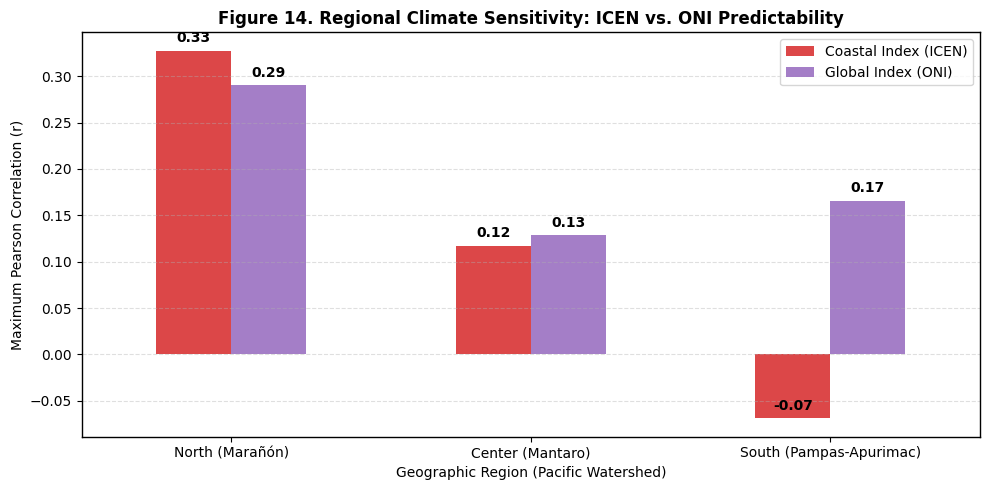

In [38]:
# ── Representative domains for the latitudinal gradient ──────────────────────
regional_targets = {
    'North (Marañón)' : 'MARAÑÓN_std',
    'Center (Mantaro)' : 'MANTARO_std',
    'South (Pampas-Apurimac)': 'PAMPAS-APURIMAC_std',
}

results_sensitivity = []
for region, domain in regional_targets.items():
    if domain in df_tws_std.columns:
        r_icen = compute_tlcc(df_enso_std['ICEN_std'], df_tws_std[domain], MAX_LAG).max()
        r_oni  = compute_tlcc(df_enso_std['ONI_std'],  df_tws_std[domain], MAX_LAG).max()
        results_sensitivity.append({'Region': region, 'ICEN_r': r_icen, 'ONI_r': r_oni})

df_sens = pd.DataFrame(results_sensitivity).set_index('Region')

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = df_sens.plot(kind='bar', figsize=(10, 5), color=['#d62728', '#9467bd'], alpha=0.85)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=10, fontweight='bold')

ax.set_title('Figure 14. Regional Climate Sensitivity: ICEN vs. ONI Predictability',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Maximum Pearson Correlation (r)')
ax.set_xlabel('Geographic Region (Pacific Watershed)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Coastal Index (ICEN)', 'Global Index (ONI)'], frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()


### 📊 Section VI — Results Summary

**Standardisation and verification (Figure 10):** The Z-score standardisation
places TWS and ENSO indices on a comparable dimensionless scale. The verification plot for Marañón illustrates the contrasting behaviour of the two indices: the ICEN tracks the TWS signal more closely in phase, while the ONI appears shifted relative to the TWS anomaly, anticipating the response by several months.

---

**TLCC with ONI** Overall correlations between the ONI and TWS are low to moderate across all 14 domains (maximum r ≈ 0.36, Huallaga at Lag = −5). The strongest positive correlations are concentrated in the
Amazonian and northern Andean domains (Huallaga, Amazonas, Marañón, Madre de
Dios), where peak correlations occur at negative lags (−4 to −6 months),
indicating that TWS anomalies in these domains precede the ONI signal rather
than lagging it. The southern Andean domains (Pampas-Apurímac, Urubamba-
Vilcanota, Titicaca, Caplina-Ocoña) show their maximum correlations at lags
of 0 to −2 months, which given the 3-month centred smoothing applied to both
series, is effectively simultaneous at the monthly resolution of GRACE. The northern coastal domains (Jequetepeque-Zarumilla, Cañete-Fortaleza, Mantaro) show the weakest and most spatially diffuse correlations with the ONI across all lags, confirming their low sensitivity to central Pacific forcing.

**TLCC with ICEN:** The ICEN produces a spatially more differentiated correlation pattern than the ONI. The strongest positive
correlations are found in Huallaga (r = 0.34, Lag = 0), Marañón (r = 0.33,
Lag = 0), and Huarmey-Chicama (r = 0.31, Lag = −1), with peak correlations for these northern domains occurring at lags of 0 to −1 months — effectively simultaneous at monthly resolution. Jequetepeque-Zarumilla also shows its maximum correlation with the ICEN at Lag = +1 (r = 0.17), slightly
positive, suggesting a marginal delay of the TWS response relative to the
coastal SST forcing in the northernmost domain. Amazonas and Ucayali show
moderate positive correlations with the ICEN at lags near zero, consistent
with the ICEN-tracking behaviour identified visually in the Hovmöller diagram.
In contrast, the southern Andean domains (Pampas-Apurímac, Urubamba-Vilcanota,
Titicaca, Caplina-Ocoña) show negative correlations with the ICEN, with peak
negative values at lags of −7 to −9 months (r ≈ −0.16 to −0.17). This
negative correlation at long negative lags is a notable finding: it indicates
that TWS deficits in the southern Andean domains tend to precede positive ICEN
anomalies by approximately 7–9 months — a lead-lag structure consistent with
the dipole pattern observed in the Hovmöller diagram, where northern surplus
and southern deficit co-occur during Coastal El Niño events.
Cháparra-Chincha and Mantaro show near-zero correlations with the ICEN across
all lags, reinforcing their role as transition domains with weak sensitivity
to either Pacific forcing mode.

---

**Comparative sensitivity: ONI vs. ICEN :**
The domain-level comparison reveals a clear latitudinal partitioning of ENSO
sensitivity. Northern coastal and northern Amazonian domains (Jequetepeque-
Zarumilla, Huarmey-Chicama, Marañón, Huallaga) are more strongly correlated
with the ICEN than with the ONI, with simultaneous peak correlations (Lag ≈ 0)
confirming that coastal SST anomalies are the primary modulator of TWS in
these basins. The Amazonian domains Amazonas and Ucayali show moderate
sensitivity to both indices but align more consistently with the ICEN at near-
zero lags. The southern Andean domains (Pampas-Apurímac, Urubamba-Vilcanota,
Titicaca, Caplina-Ocoña) show their highest correlations with the ONI at near-
simultaneous lags, making the ONI the better statistical predictor for these
basins. The central domains (Cañete-Fortaleza, Mantaro, Cháparra-Chincha)
show uniformly weak correlations with both indices across all lags, confirming
their role as a transitional zone with limited sensitivity to either Pacific
forcing mode at the monthly timescale resolved by GRACE.

# VII. C and E Index Teleconnections

This section extends the ENSO teleconnection analysis using the **C and E indices** developed by Takahashi et al. (2011), available from the Instituto Geofísico del Perú (IGP). These indices decompose ENSO variability into two orthogonal modes:

- **C index (Cold Tongue mode):** Captures the canonical, basin-wide El Niño pattern associated with equatorial Pacific cooling/warming. Closely related to the ONI.
- **E index (El Niño Modoki / Warm Pool mode):** Captures the non-canonical, Central Pacific ENSO pattern with stronger influence on the western Pacific and higher-latitude teleconnections.

Using both indices allows us to determine whether the TWS response in Peru is driven by the canonical cold-tongue ENSO mode, the warm-pool mode, or a combination of both.

**Data source:** IGP — [http://met.igp.gob.pe/variabclim/indices.html](http://met.igp.gob.pe/variabclim/indices.html)


## 7.1. Loading and Inspecting C & E Index Data

The C and E indices are loaded from the repository, inspected for NaN values, and imputed using quadratic interpolation where needed.


In [ ]:
# ── File path ─────────────────────────────────────────────────────────────────
CEINDEX_PATH = os.path.join(REPO_NAME, "data/enso/ecindex_ersstv5.csv")

if os.path.exists(CEINDEX_PATH):
    df_enso_ce = pd.read_csv(CEINDEX_PATH, index_col='time', parse_dates=True)
    print(f"✓ C & E index loaded | {len(df_enso_ce)} months | Columns: {list(df_enso_ce.columns)}")
else:
    raise FileNotFoundError(f"C & E index file not found at '{CEINDEX_PATH}'.")

# ── Preliminary visualisation: raw data ───────────────────────────────────────
START_DATE, END_DATE = '2002-01-01', '2025-12-01'
df_ce_filtered = df_enso_ce.loc[START_DATE:END_DATE]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df_ce_filtered.index, df_ce_filtered['C_index'],
             color='steelblue', linewidth=1.5, label='C index')
axes[0].set_title('C index — Raw Time Series (2002–2025)', fontweight='bold')
axes[0].set_ylabel('C index')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(df_ce_filtered.index, df_ce_filtered['E_index'],
             color='firebrick', linewidth=1.5, label='E index')
axes[1].set_title('E index — Raw Time Series (2002–2025)', fontweight='bold')
axes[1].set_ylabel('E index')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close()


In [ ]:
# ── NaN check and quadratic imputation ───────────────────────────────────────
# Quadratic interpolation fits a local polynomial to estimate missing values,
# preserving the curvature of the surrounding signal.
print("NaNs before imputation:")
print(df_enso_ce.isnull().sum())

df_enso_curated = df_enso_ce.interpolate(method='quadratic')

print("NaNs after imputation:")
print(df_enso_curated.isnull().sum())
display(df_enso_curated.head())


In [ ]:
# ── Centred 3-month moving average (consistent with TWS smoothing) ────────────
df_enso_smoothed = df_enso_curated.rolling(window=3, center=True, min_periods=2).mean()
print("✓ 3-month centred moving average applied to C & E indices.")
print(f"  Shape: {df_enso_smoothed.shape}")
display(df_enso_smoothed.head())


## 7.2. Additive Decomposition of C & E Indices

The same additive decomposition pipeline used for TWS in Section IV is applied to the C and E indices, separating their seasonal cycle from the inter-annual anomaly signal used for TLCC.


In [42]:
# ── Drop smoothing-edge NaNs ─────────────────────────────────────────────────
df_enso_clean = df_enso_smoothed.dropna()

# ── Decompose C index ─────────────────────────────────────────────────────────
result_cindex = seasonal_decompose(df_enso_clean['C_index'], model='additive',
                                   period=12, extrapolate_trend='freq')
df_cindex_seasonal  = result_cindex.seasonal.to_frame(name='C_index_seasonal')
df_cindex_deseasonal = (result_cindex.trend + result_cindex.resid).to_frame(name='C_index_deseasonal')
print("✓ C index decomposition complete.")

# ── Decompose E index ─────────────────────────────────────────────────────────
result_eindex = seasonal_decompose(df_enso_clean['E_index'], model='additive',
                                   period=12, extrapolate_trend='freq')
df_eindex_seasonal   = result_eindex.seasonal.to_frame(name='E_index_seasonal')
df_eindex_deseasonal = (result_eindex.trend + result_eindex.resid).to_frame(name='E_index_deseasonal')
print("✓ E index decomposition complete.")


✓ C index decomposition complete.
✓ E index decomposition complete.


## 7.3. Seasonal Components of C & E Indices

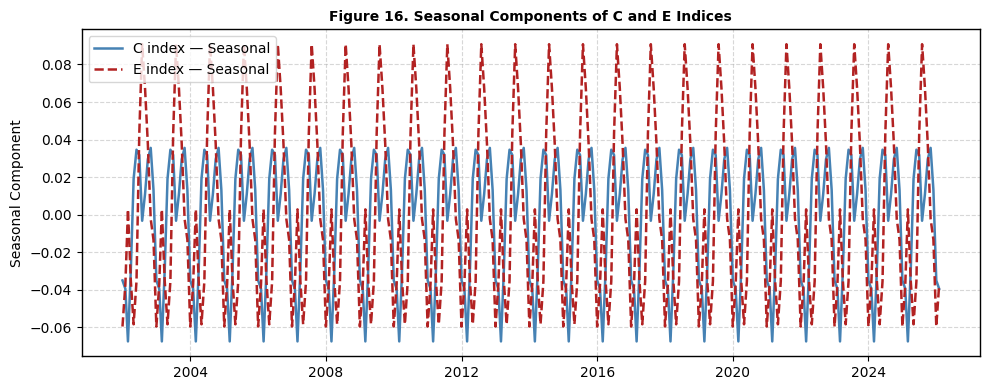

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_cindex_seasonal.index, df_cindex_seasonal['C_index_seasonal'],
        label='C index — Seasonal', color='steelblue', linewidth=1.8)
ax.plot(df_eindex_seasonal.index, df_eindex_seasonal['E_index_seasonal'],
        label='E index — Seasonal', color='firebrick', linewidth=1.8, linestyle='--')
ax.set_title('Figure 16. Seasonal Components of C and E Indices', fontweight='bold')
ax.set_ylabel('Seasonal Component')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()
plt.close()


## 7.4. Deseasonalized C & E Indices with ENSO Event Markers

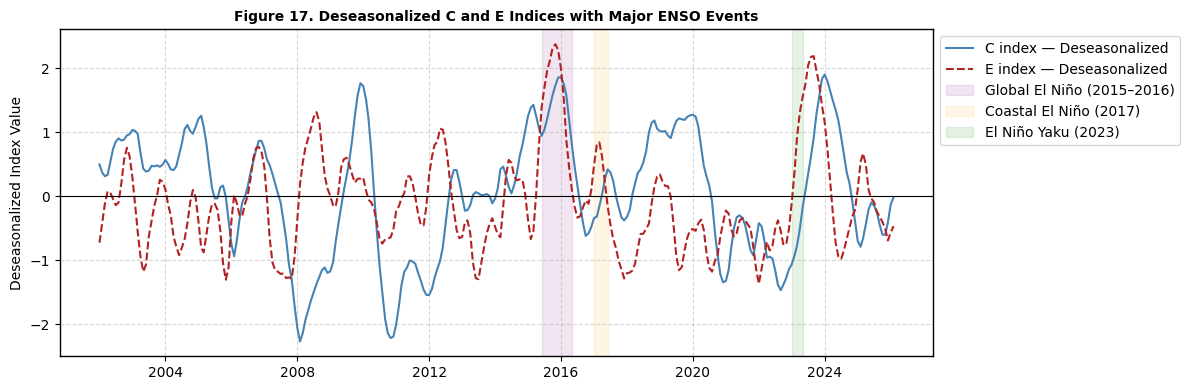

In [44]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_cindex_deseasonal.index, df_cindex_deseasonal['C_index_deseasonal'],
        label='C index — Deseasonalized', color='steelblue', linewidth=1.5)
ax.plot(df_eindex_deseasonal.index, df_eindex_deseasonal['E_index_deseasonal'],
        label='E index — Deseasonalized', color='firebrick', linewidth=1.5, linestyle='--')

# ENSO event shading
ax.axvspan(pd.Timestamp('2015-06-01'), pd.Timestamp('2016-05-01'),
           color='purple', alpha=0.10, label='Global El Niño (2015–2016)')
ax.axvspan(pd.Timestamp('2017-01-01'), pd.Timestamp('2017-06-01'),
           color='orange', alpha=0.10, label='Coastal El Niño (2017)')
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-05-01'),
           color='green',  alpha=0.10, label='El Niño Yaku (2023)')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Figure 17. Deseasonalized C and E Indices with Major ENSO Events',
             fontweight='bold')
ax.set_ylabel('Deseasonalized Index Value')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.tight_layout()
plt.show()
plt.close()


## 7.5. Hovmöller Diagram: C & E Indices vs. TWS

/tmp/ipykernel_4988/1515776227.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


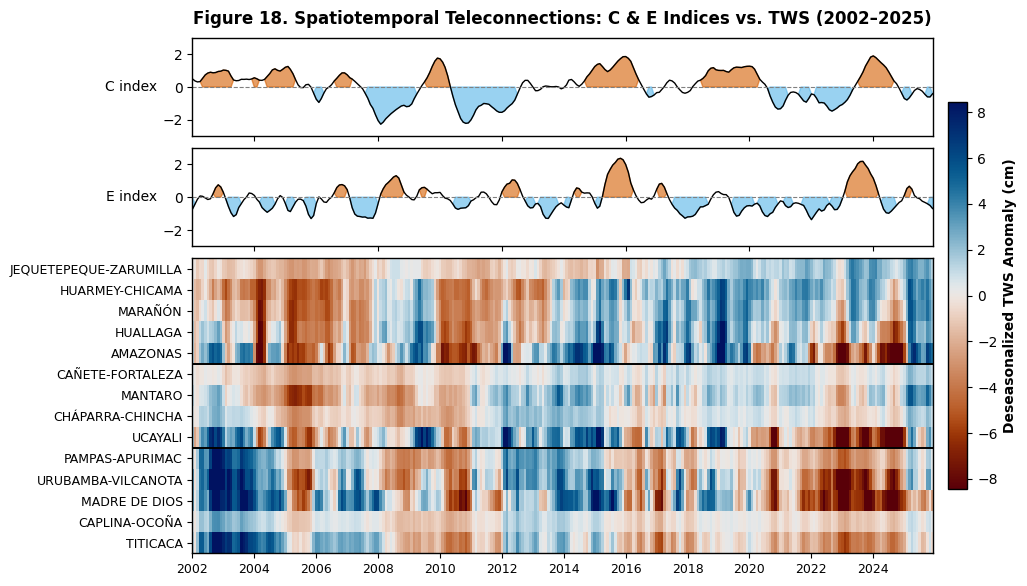

In [45]:
# ── Align C & E indices with TWS time axis ───────────────────────────────────
common_time = df_deseasonalized_ordered.index.intersection(df_cindex_deseasonal.index)
df_cindex_aligned = df_cindex_deseasonal.loc[common_time, 'C_index_deseasonal']
df_eindex_aligned = df_eindex_deseasonal.loc[common_time, 'E_index_deseasonal']

# Reuse data_matrix from Section 5.2 (same TWS order and time axis)
vmax_ce = np.nanpercentile(np.abs(data_matrix), 98)
vmin_ce = -vmax_ce

# ── Multi-panel figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
gs  = gridspec.GridSpec(5, 1, height_ratios=[1, 1, 3, 0, 0], hspace=0.12)

ax_c   = fig.add_subplot(gs[0])
ax_e   = fig.add_subplot(gs[1])
ax_tws = fig.add_subplot(gs[2])

# Panel A: C index
ax_c.plot(df_cindex_aligned.index, df_cindex_aligned, color='black', linewidth=1)
ax_c.fill_between(df_cindex_aligned.index, df_cindex_aligned, 0,
                  where=(df_cindex_aligned >= 0.5),  color='#D55E00', alpha=0.6, interpolate=True)
ax_c.fill_between(df_cindex_aligned.index, df_cindex_aligned, 0,
                  where=(df_cindex_aligned <= -0.5), color='#56B4E9', alpha=0.6, interpolate=True)
ax_c.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_c.set_ylabel('C index', rotation=0, ha='right', va='center', fontsize=10)
ax_c.set_ylim(-3, 3)
ax_c.tick_params(axis='x', labelbottom=False)
ax_c.set_title('Figure 18. Spatiotemporal Teleconnections: C & E Indices vs. TWS (2002–2025)',
               fontsize=12, fontweight='bold', pad=10)

# Panel B: E index
ax_e.plot(df_eindex_aligned.index, df_eindex_aligned, color='black', linewidth=1)
ax_e.fill_between(df_eindex_aligned.index, df_eindex_aligned, 0,
                  where=(df_eindex_aligned >= 0.5),  color='#D55E00', alpha=0.6, interpolate=True)
ax_e.fill_between(df_eindex_aligned.index, df_eindex_aligned, 0,
                  where=(df_eindex_aligned <= -0.5), color='#56B4E9', alpha=0.6, interpolate=True)
ax_e.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_e.set_ylabel('E index', rotation=0, ha='right', va='center', fontsize=10)
ax_e.set_ylim(-3, 3)
ax_e.tick_params(axis='x', labelbottom=False)

# Panel C: TWS Hovmöller
mesh = ax_tws.pcolormesh(fechas_tws, np.arange(len(dominios)), data_matrix,
                         cmap=cmc.vik_r, vmin=vmin_ce, vmax=vmax_ce, shading='nearest')
ax_tws.set_yticks(np.arange(len(dominios)))
ax_tws.set_yticklabels(dominios, fontsize=9)
ax_tws.invert_yaxis()
ax_tws.axhline(4.5, color='black', linewidth=1.4)
ax_tws.axhline(8.5, color='black', linewidth=1.4)

for ax in [ax_c, ax_e, ax_tws]:
    ax.set_xlim(common_time.min(), common_time.max())
ax_tws.xaxis.set_major_locator(mdates.YearLocator(2))
ax_tws.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax_tws.xaxis.get_majorticklabels(), fontsize=9)

cbar = fig.colorbar(mesh, ax=[ax_c, ax_e, ax_tws],
                    orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('Deseasonalized TWS Anomaly (cm)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()


## 7.6. Standardisation of C & E Indices and TWS

In [48]:
# ── Align time index before standardising ────────────────────────────────────
common_idx = df_cindex_deseasonal.index.intersection(df_deseasonalized_ordered.index)

c_idx_aligned = df_cindex_deseasonal.loc[common_idx, ['C_index_deseasonal']]
e_idx_aligned = df_eindex_deseasonal.loc[common_idx, ['E_index_deseasonal']]

c_index_deseasonal_std = pd.DataFrame(
    scaler.fit_transform(c_idx_aligned),
    index=common_idx, columns=['C_index_deseasonal_std']
)
e_index_deseasonal_std = pd.DataFrame(
    scaler.fit_transform(e_idx_aligned),
    index=common_idx, columns=['E_index_deseasonal_std']
)

# Standardise all 14 TWS domains over the common index
df_deseasonalized_ordered_std = pd.DataFrame(index=common_idx)
for domain in df_deseasonalized_ordered.columns:
    series_data = df_deseasonalized_ordered.loc[common_idx, domain].values.reshape(-1, 1)
    df_deseasonalized_ordered_std[f"{domain}_std"] = scaler.fit_transform(series_data)

print("✓ C index, E index, and TWS domains standardised over the common time window.")
print(f"  Common period: {common_idx.min().date()} → {common_idx.max().date()} | {len(common_idx)} months")


✓ C index, E index, and TWS domains standardised over the common time window.
  Common period: 2002-01-01 → 2025-12-01 | 288 months


## 7.7. TLCC: C Index vs. TWS (All Domains)

Reference domain : C INDEX
Lag range        : ±12 months


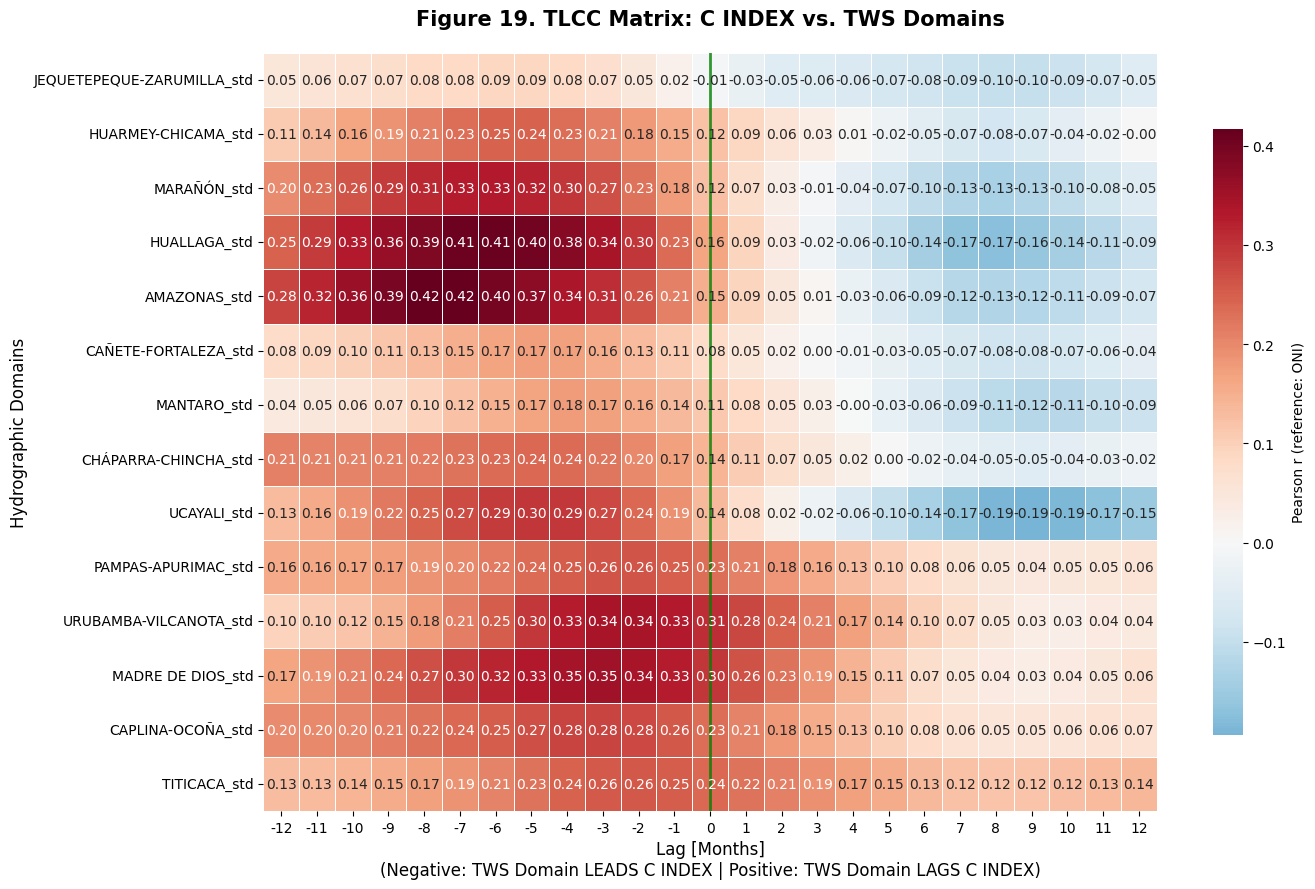

In [50]:
# ── TLCC: C index vs. all domains ─────────────────────────────────────────────
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# ── Configuration ─────────────────────────────────────────────────────────────
MAX_LAG = 12  # Range of +/- 12 months


# Use the already standardized C INDEX series
cindex_ref = c_index_deseasonal_std['C_index_deseasonal_std']

tlcc_cindex_results = {
    domain_col: compute_tlcc(cindex_ref, df_deseasonalized_ordered_std[domain_col], MAX_LAG)
    for domain_col in df_deseasonalized_ordered_std.columns
}

# ── Compute TLCC for all domains against the reference ────────────────────────
print(f"Reference domain : C INDEX")
print(f"Lag range        : ±{MAX_LAG} months")

# Iterate through standardized TWS domains
for domain_col_std in df_tws_std.columns:
    target_series = df_tws_std[domain_col_std]
    tlcc_cindex_results[domain_col_std] = compute_tlcc(cindex_ref, target_series, MAX_LAG)

df_tlcc_cindex_matrix = pd.DataFrame(tlcc_cindex_results).T

# ── TLCC Heatmap ──────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_cindex_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': f'Pearson r (reference: ONI)', 'shrink': 0.8})

plt.title(f'Figure 19. TLCC Matrix: C INDEX vs. TWS Domains',
          fontweight='bold', fontsize=15, pad=20)
plt.xlabel(f'Lag [Months]\n(Negative: TWS Domain LEADS C INDEX | Positive: TWS Domain LAGS C INDEX)',
           fontsize=12)
plt.ylabel('Hydrographic Domains', fontsize=12)

plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

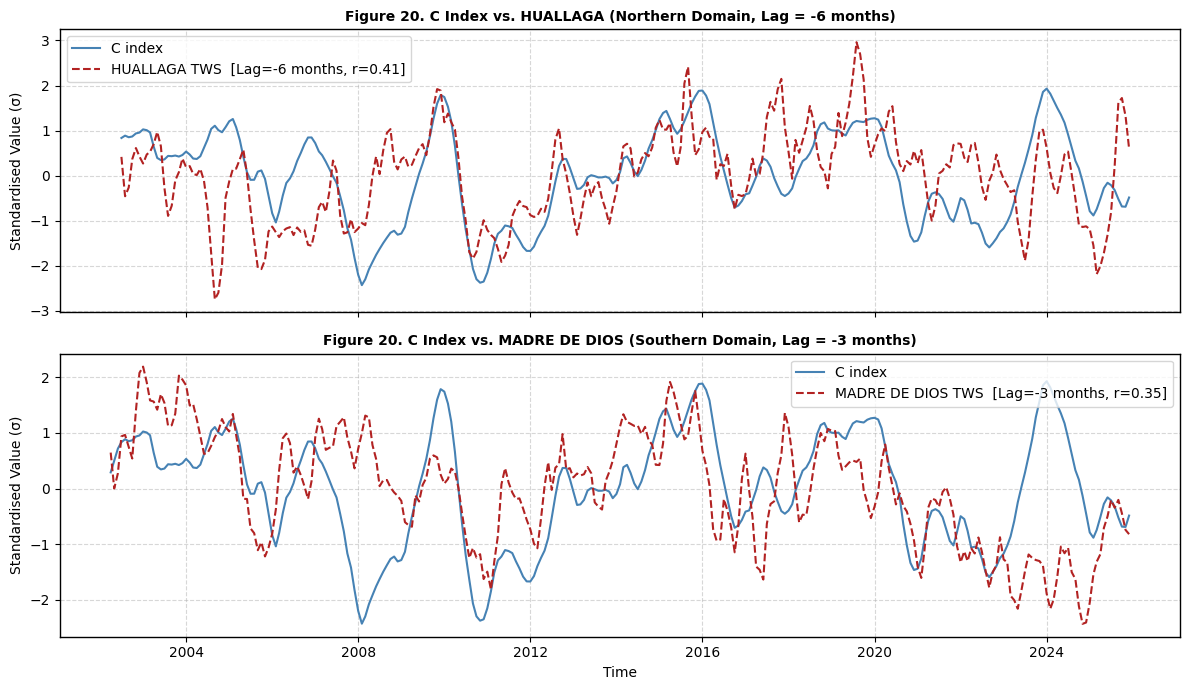

In [51]:
# ── Lag-shifted overlay: C index vs. selected North and South domains ─────────
# Restore named index for lookup
df_tlcc_cindex_named = pd.DataFrame(tlcc_cindex_results).T

NORTHERN_DOMAIN = 'HUALLAGA'
SOUTHERN_DOMAIN = 'MADRE DE DIOS'
LAG_NORTH = -6   # adjust based on TLCC matrix inspection
LAG_SOUTH = -3   # adjust based on TLCC matrix inspection

cindex_std_series = c_index_deseasonal_std['C_index_deseasonal_std']

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, domain, lag, title_suffix in zip(
    axes,
    [NORTHERN_DOMAIN, SOUTHERN_DOMAIN],
    [LAG_NORTH, LAG_SOUTH],
    ['Northern Domain', 'Southern Domain']
):
    tws_std   = df_deseasonalized_ordered_std[f'{domain}_std']
    tws_shift = tws_std.shift(-lag)
    common    = cindex_std_series.index.intersection(tws_shift.dropna().index)
    r_val     = df_tlcc_cindex_named.loc[f'{domain}_std', lag]

    ax.plot(cindex_std_series.loc[common], color='steelblue', linewidth=1.5, label='C index')
    ax.plot(tws_shift.loc[common], color='firebrick', linewidth=1.5, linestyle='--',
            label=f'{domain} TWS  [Lag={lag} months, r={r_val:.2f}]')
    ax.set_title(f'Figure 20. C Index vs. {domain} ({title_suffix}, Lag = {lag} months)',
                 fontweight='bold')
    ax.set_ylabel('Standardised Value (σ)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()
plt.close()


## 7.8. TLCC: E Index vs. TWS (All Domains)

Reference domain : E INDEX
Lag range        : ±12 months


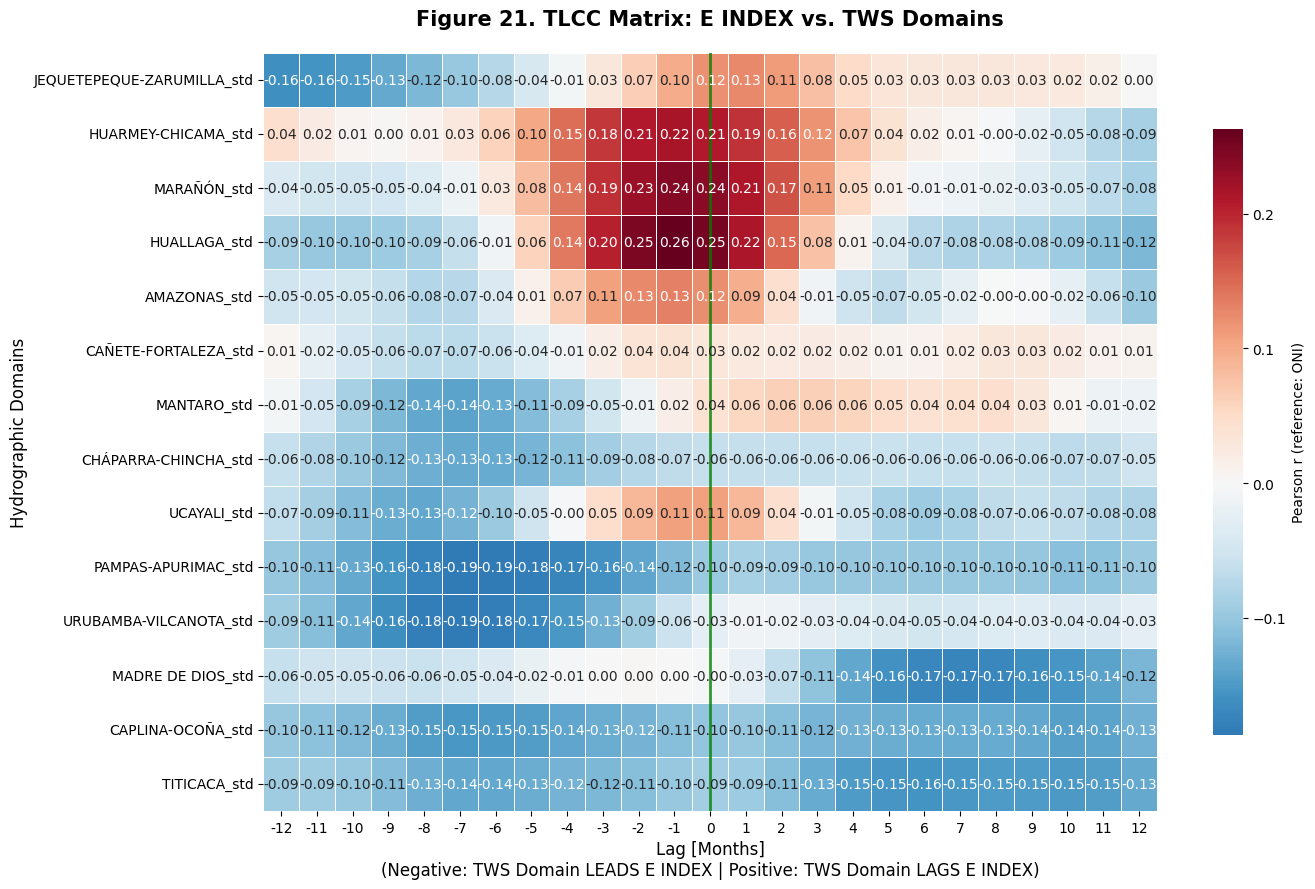

In [53]:
# ── TLCC: E index vs. all domains ─────────────────────────────────────────────
def compute_tlcc(series_ref, series_target, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    for lag in lags:
        # Correlation between ref(t) and target(t + lag)
        corr = series_ref.corr(series_target.shift(-lag))
        correlations.append(corr)
    return pd.Series(correlations, index=lags)

# ── Configuration ─────────────────────────────────────────────────────────────
MAX_LAG = 12  # Range of +/- 12 months


# Use the already standardized C INDEX series
eindex_ref = e_index_deseasonal_std['E_index_deseasonal_std']

tlcc_eindex_results = {
    domain_col: compute_tlcc(eindex_ref, df_deseasonalized_ordered_std[domain_col], MAX_LAG)
    for domain_col in df_deseasonalized_ordered_std.columns
}

# ── Compute TLCC for all domains against the reference ────────────────────────
print(f"Reference domain : E INDEX")
print(f"Lag range        : ±{MAX_LAG} months")

# Iterate through standardized TWS domains
for domain_col_std in df_tws_std.columns:
    target_series = df_tws_std[domain_col_std]
    tlcc_eindex_results[domain_col_std] = compute_tlcc(eindex_ref, target_series, MAX_LAG)


df_tlcc_eindex_matrix = pd.DataFrame(tlcc_eindex_results).T

# ── TLCC Heatmap ──────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 9))
sns.heatmap(df_tlcc_eindex_matrix,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': f'Pearson r (reference: ONI)', 'shrink': 0.8})

plt.title(f'Figure 21. TLCC Matrix: E INDEX vs. TWS Domains',
          fontweight='bold', fontsize=15, pad=20)
plt.xlabel(f'Lag [Months]\n(Negative: TWS Domain LEADS E INDEX | Positive: TWS Domain LAGS E INDEX)',
           fontsize=12)
plt.ylabel('Hydrographic Domains', fontsize=12)

plt.axvline(x=MAX_LAG + 0.5, color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()
plt.close()

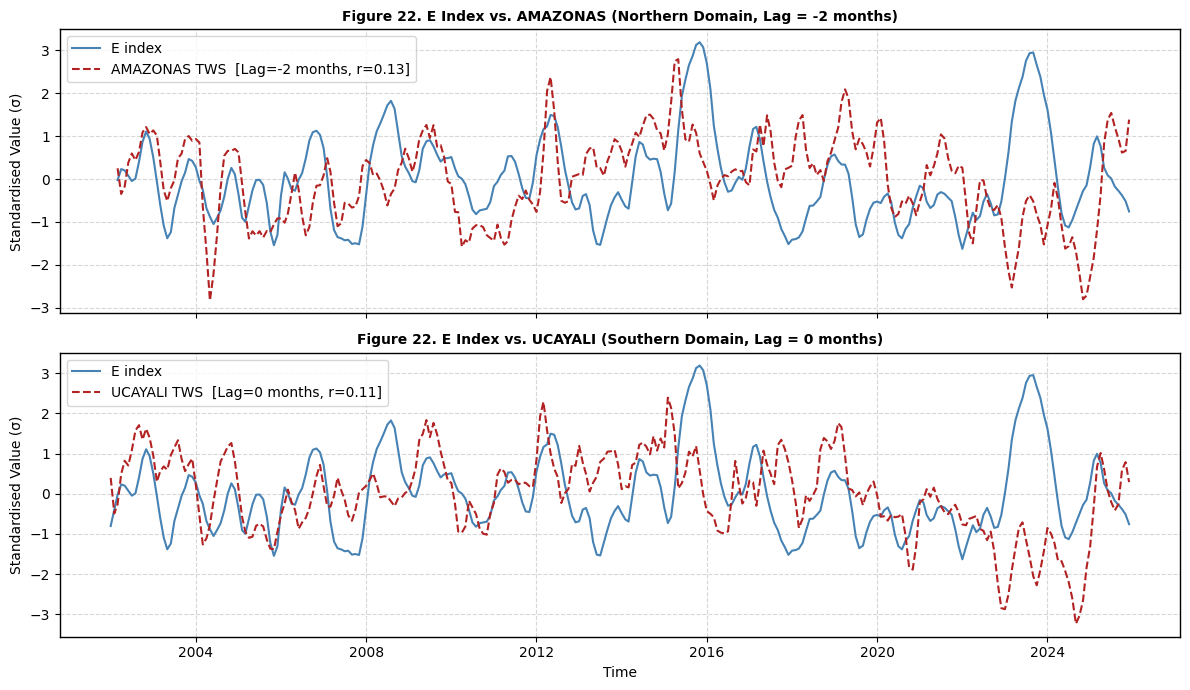

In [54]:
# ── Lag-shifted overlay: E index vs. selected North and South domains ─────────
df_tlcc_eindex_named = pd.DataFrame(tlcc_eindex_results).T

NORTHERN_DOMAIN_E = 'AMAZONAS'
SOUTHERN_DOMAIN_E = 'UCAYALI'
LAG_NORTH_E = -2   # adjust based on TLCC matrix inspection
LAG_SOUTH_E =  0   # adjust based on TLCC matrix inspection

eindex_std_series = e_index_deseasonal_std['E_index_deseasonal_std']

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, domain, lag, title_suffix in zip(
    axes,
    [NORTHERN_DOMAIN_E, SOUTHERN_DOMAIN_E],
    [LAG_NORTH_E, LAG_SOUTH_E],
    ['Northern Domain', 'Southern Domain']
):
    tws_std   = df_deseasonalized_ordered_std[f'{domain}_std']
    tws_shift = tws_std.shift(-lag)
    common    = eindex_std_series.index.intersection(tws_shift.dropna().index)
    r_val     = df_tlcc_eindex_named.loc[f'{domain}_std', lag]

    ax.plot(eindex_std_series.loc[common], color='steelblue', linewidth=1.5, label='E index')
    ax.plot(tws_shift.loc[common], color='firebrick', linewidth=1.5, linestyle='--',
            label=f'{domain} TWS  [Lag={lag} months, r={r_val:.2f}]')
    ax.set_title(f'Figure 22. E Index vs. {domain} ({title_suffix}, Lag = {lag} months)',
                 fontweight='bold')
    ax.set_ylabel('Standardised Value (σ)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()
plt.close()


### 📊 Section VII — Results Summary

**Hovmöller C & E Indices vs. TWS (Figure 18):** The spatiotemporal pattern
of the TWS Hovmöller diagram is virtually identical to that obtained with the
ONI and ICEN (Figure 6), confirming the robustness of the North–South dipole
structure across different ENSO index formulations. The C index temporal
evolution closely mirrors the ONI, capturing the same canonical warm and cold
phase sequences. The E index shows a distinct temporal structure with more
frequent and shorter-duration positive anomalies, and notably captures the
2009–2010 warm event more prominently than the C index — an episode that
corresponds to a Central Pacific (Modoki-type) El Niño not well represented
by the ONI signal.

---

**TLCC with C Index:** The C index produces the highest overall correlations of the four indices analysed (ONI, ICEN, C, E), with maximum values reaching r = 0.42 for Amazonas and Huallaga at lags of −7 to −8
months, and r = 0.41 for Huallaga at Lag = −6. These peak correlations at negative lags indicate that TWS anomalies in the northern and central Amazonian domains lead the C index by 6–8 months. The southern Andean
domains (Urubamba-Vilcanota, Caplina-Ocoña, Pampas-Apurímac, Titicaca) and
Madre de Dios show moderate positive correlations (r = 0.23–0.35) at near-
simultaneous lags (0 to −3 months), broadly consistent with the ONI pattern.
Cháparra-Chincha shows an unexpected moderate positive correlation with the
C index (r ≈ 0.24 at Lag = −4 to −5), in contrast to its near-zero response
to the ONI and ICEN, suggesting a weak but detectable sensitivity to the
Cold Tongue ENSO mode in this central coastal domain. Jequetepeque-Zarumilla
remains the domain with the weakest and most spatially diffuse correlations,
showing near-zero values across all lags.

**TLCC with E Index:** The E index produces the most spatially differentiated and contrasting correlation pattern of all four
indices. Huallaga shows the strongest positive correlations (r = 0.26 at
Lag = 0 to −1), followed by Marañón (r = 0.24 at Lag = 0) and Huarmey-Chicama (r = 0.22 at Lag = −1). These northern domains respond
positively and near-simultaneously to the E index, consistent with the Central Pacific warm pool ENSO mode producing precipitation anomalies over the northern Peruvian watershed. In sharp contrast, the southern Andean domains (Pampas-Apurímac, Urubamba-Vilcanota, Titicaca, Caplina-Ocoña) show negative correlations with the E index across nearly all lags, with peak
negative values at lags of −7 to −9 months (r = −0.14 to −0.19). This
negative relationship — where southern Andean TWS deficits precede positive
E index anomalies — mirrors the dipole structure identified in the Hovmöller
and reinforces the opposing hydrological responses of the northern and
southern domains to Central Pacific ENSO forcing. Madre de Dios and Ucayali
show near-zero to weakly negative correlations at most lags, with Madre de
Dios becoming increasingly negative at positive lags (r = −0.17 at
Lag = +7 to +8), suggesting a delayed negative response of this southern
Amazonian domain to the E index forcing. Jequetepeque-Zarumilla is the only
domain that shows a sign reversal with the E index in the opposite direction
to all others: negative correlations at negative lags transitioning to weakly
positive values at near-zero and positive lags (r = +0.13 at Lag = +1),
indicating a marginal delayed positive response to Central Pacific warming
that is unique among the 14 domains. Cañete-Fortaleza and Mantaro show
near-zero correlations with the E index across all lags, confirming their
role as transitional domains insensitive to both Pacific forcing modes.

---

**Comparative summary across all four indices (ONI, ICEN, C, E):**
The four-index TLCC analysis reveals a consistent latitudinal partitioning
of ENSO sensitivity across the Peruvian hydrographic domains:

- **Northern coastal and northern Amazonian domains** (Jequetepeque-Zarumilla,
  Huarmey-Chicama, Marañón, Huallaga) respond most strongly and near-
  simultaneously (Lag ≈ 0) to the ICEN and E index, confirming the dominance
  of coastal and Central Pacific SST forcing for these basins.
- **Amazonian domains** (Huallaga, Amazonas, Ucayali) show the highest
  absolute correlations with the C index at negative lags (−6 to −8 months),
  indicating that TWS anomalies in these basins lead the canonical Cold Tongue
  ENSO signal — a lead-lag structure not captured by the ONI or ICEN alone.

- **Southern Andean domains** (Pampas-Apurímac, Urubamba-Vilcanota, Titicaca,  Caplina-Ocoña) show their best correlations with the ONI and C index at   near-simultaneous lags, and consistent negative correlations with the ICEN and E index at long negative lags, reinforcing the opposing dipole response of southern Peru to coastal and Central Pacific forcing.

- **Central transitional domains** (Cañete-Fortaleza, Mantaro, Cháparra-
  Chincha) consistently show the weakest correlations across all four indices
  and all lags, identifying them as a hydrologically decoupled zone with
  limited statistical sensitivity to Pacific SST forcing at the monthly
  timescale resolved by GRACE.